In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load results
RESULTS_DF = "../data/results.parquet"
results_df = pd.read_parquet(RESULTS_DF)

In [3]:
# Map status
STATUS_MAP = {
    "success": "success",
    "failed": "failed",
    "timeout (600 seconds)": "timeout",
    "pending": "failed",
    # "skipped": "failed",
    "partial_success": "partial_success",
    "skipped": "skipped",
}
STATUS_COLORS = {
    "success": "green",
    "partial_success": "gold",
    "failed": "red",
    "timeout": "orange",
    "skipped": "grey",
}
results_df["status"] = results_df["status"].map(STATUS_MAP)

In [4]:
# Calculate percentages by benchmark and partitioner
results_by_bench_part = results_df.groupby(["benchmark", "partitioner"])["status"].value_counts(normalize=True).unstack(fill_value=0) * 100

# Calculate percentages by partitioner only
results_by_part = results_df.groupby("partitioner")["status"].value_counts(normalize=True).unstack(fill_value=0) * 100

# Display by benchmark and partitioner
print("Status percentages by Benchmark and Partitioner:")
print(results_by_bench_part.round(2))
print("\n" + "="*80 + "\n")

# Display by partitioner only
print("Status percentages by Partitioner (overall):")
print(results_by_part.round(2))

Status percentages by Benchmark and Partitioner:
status                                       failed  partial_success  skipped  \
benchmark                    partitioner                                        
disqco.mfpqc.cp_scaling.f0p3 fgp               0.00             0.00     0.00   
                             fgp-roee          0.00             0.00     0.00   
                             mlfm-r            3.41             0.00     0.00   
                             pytket-dqc-esd    0.00            49.55     0.00   
                             pytket-dqc-p      0.00            45.91     0.00   
                             pytket-dqc-pe     0.00            45.45     0.00   
disqco.mfpqc.cp_scaling.f0p5 fgp               0.00             0.00     0.00   
                             fgp-roee          0.00             0.00     0.00   
                             mlfm-r            1.82             0.00     0.00   
                             pytket-dqc-esd    0.00         

<Figure size 1000x600 with 0 Axes>

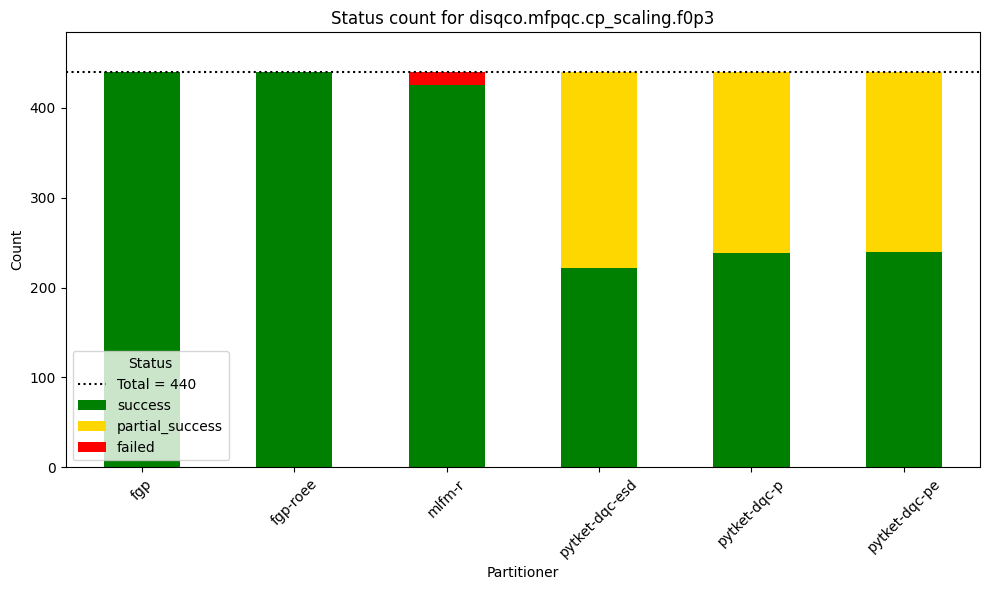

<Figure size 1000x600 with 0 Axes>

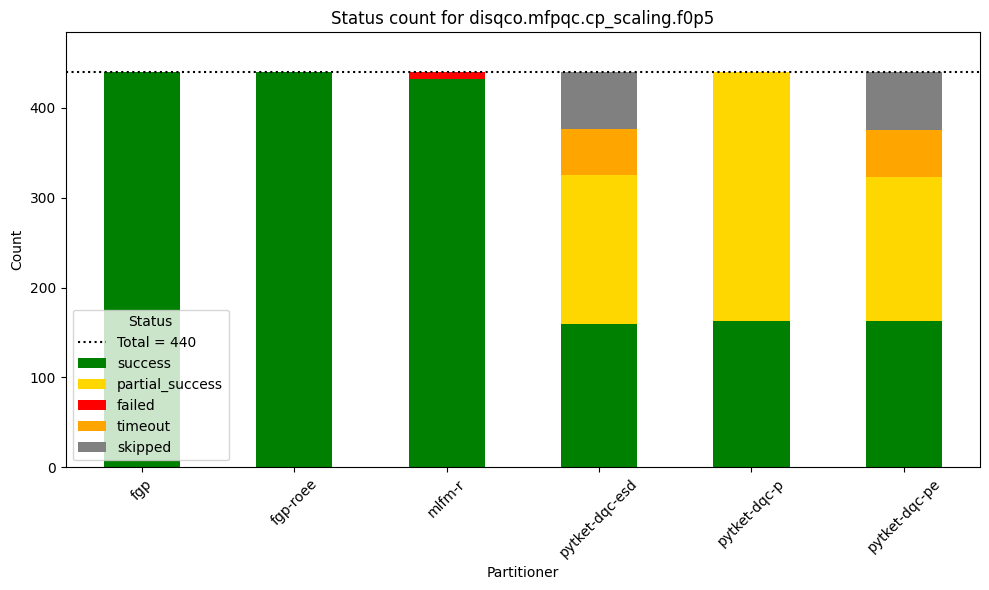

<Figure size 1000x600 with 0 Axes>

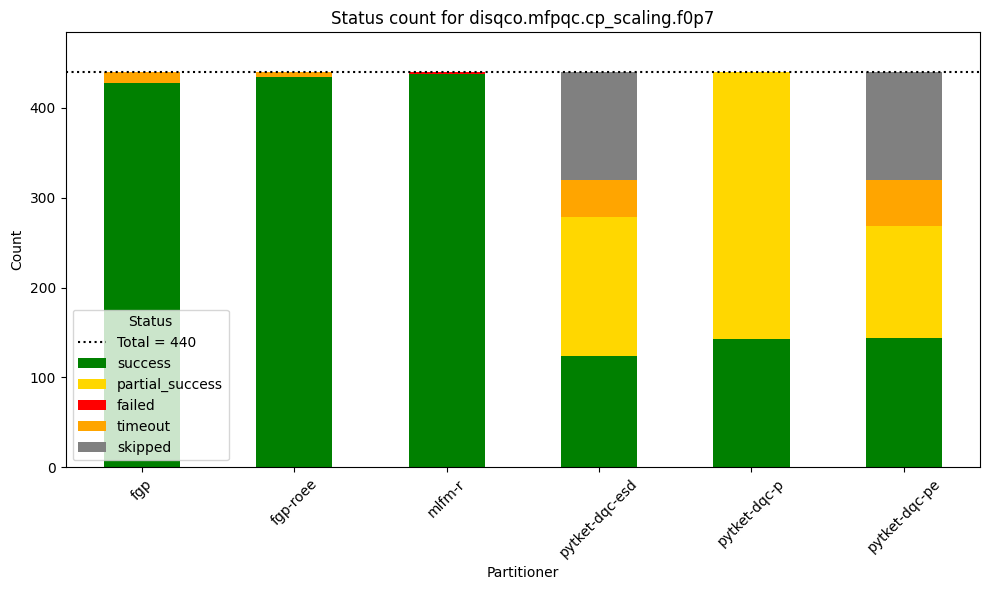

<Figure size 1000x600 with 0 Axes>

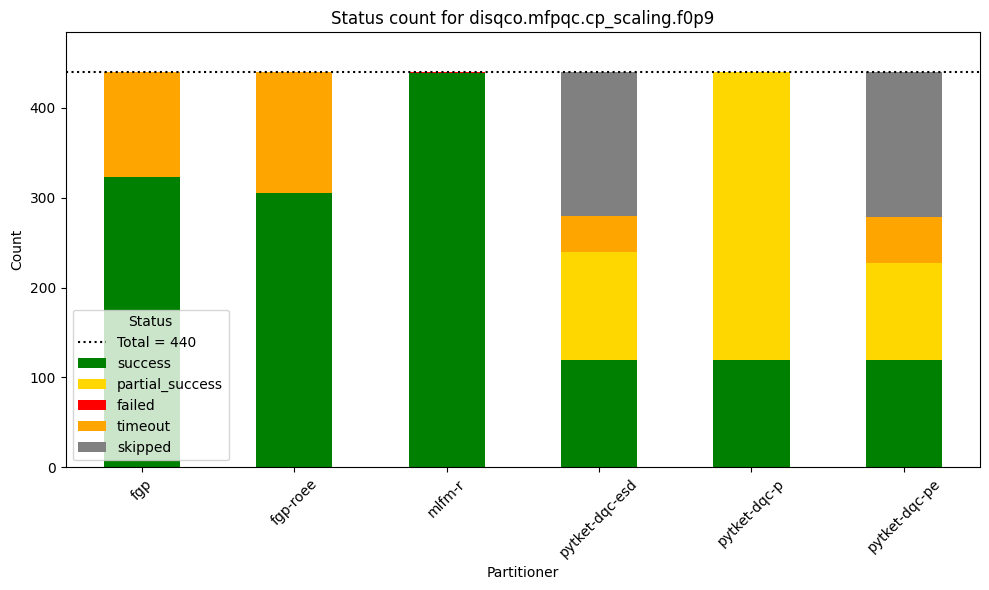

<Figure size 1000x600 with 0 Axes>

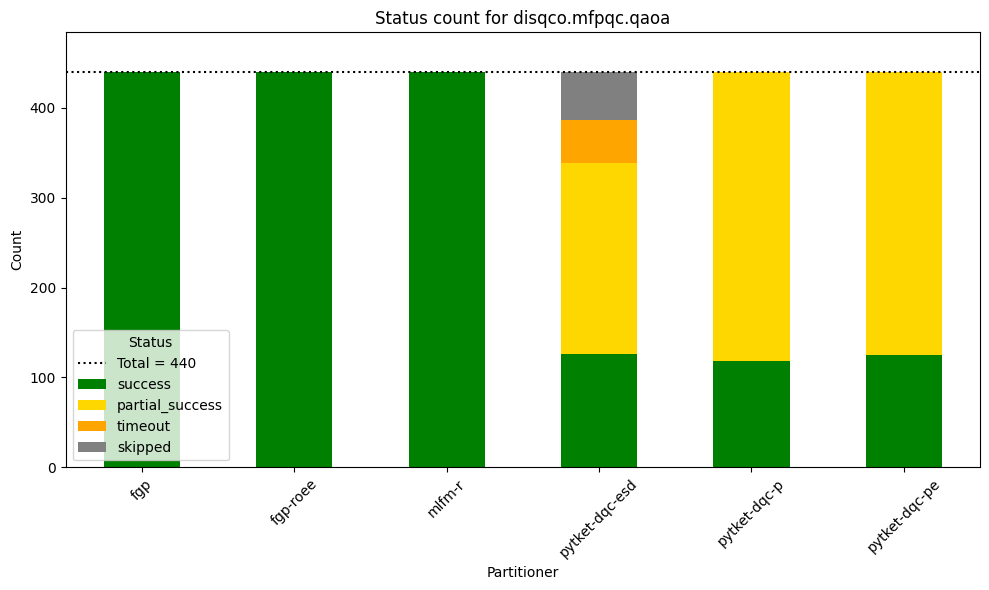

<Figure size 1000x600 with 0 Axes>

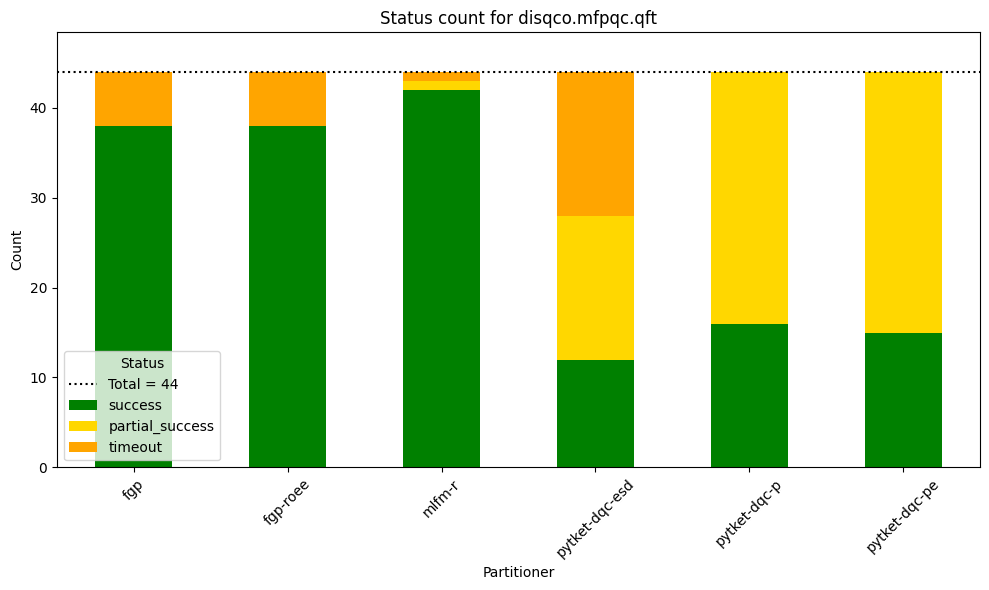

<Figure size 1000x600 with 0 Axes>

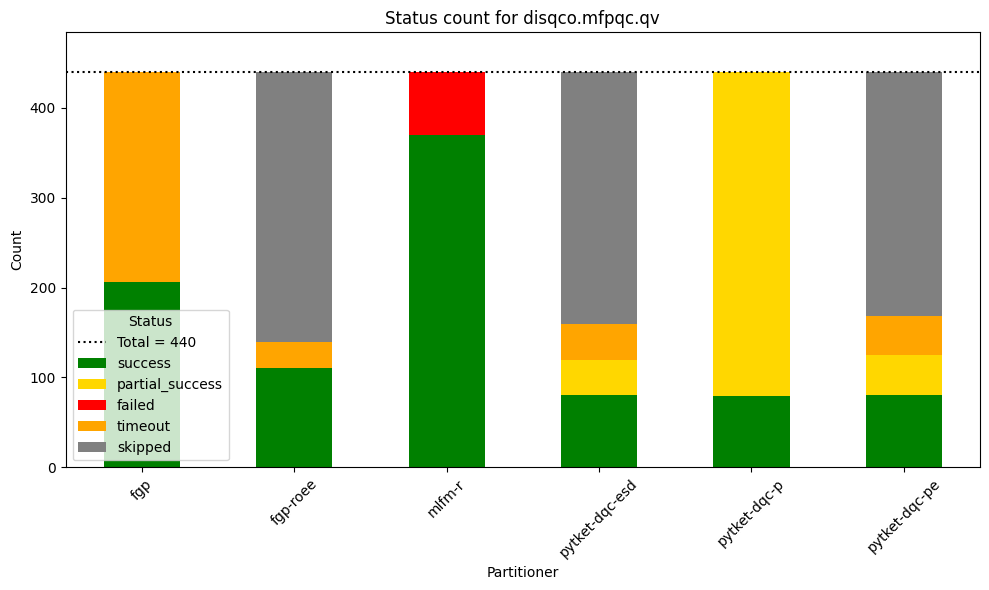

<Figure size 1000x600 with 0 Axes>

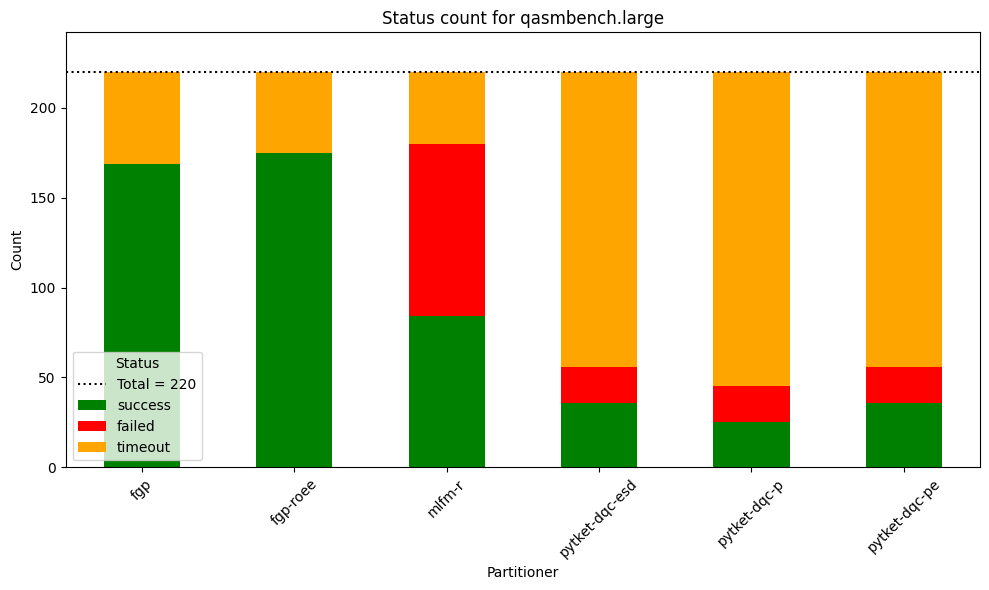

<Figure size 1000x600 with 0 Axes>

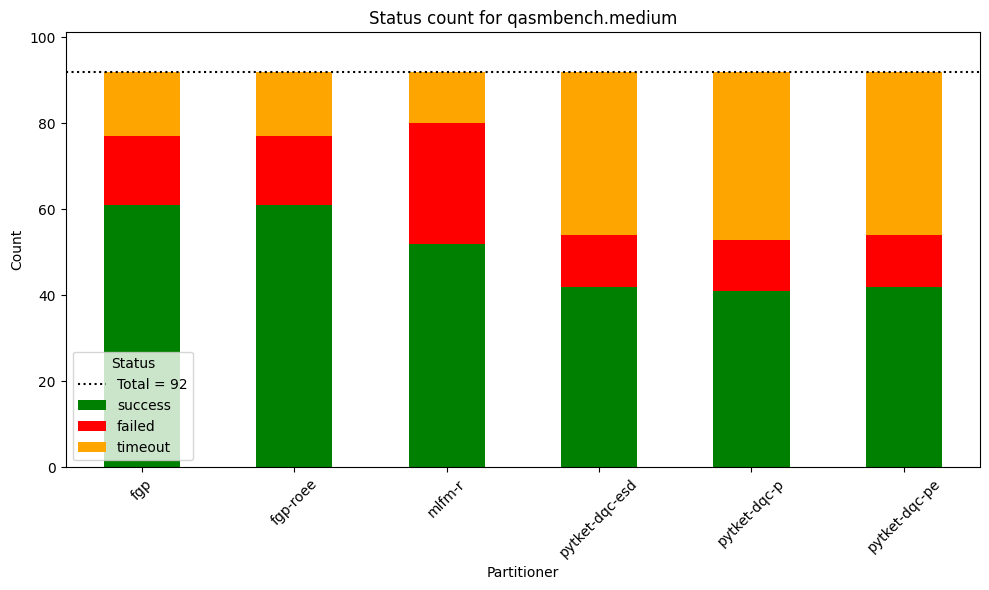

<Figure size 1000x600 with 0 Axes>

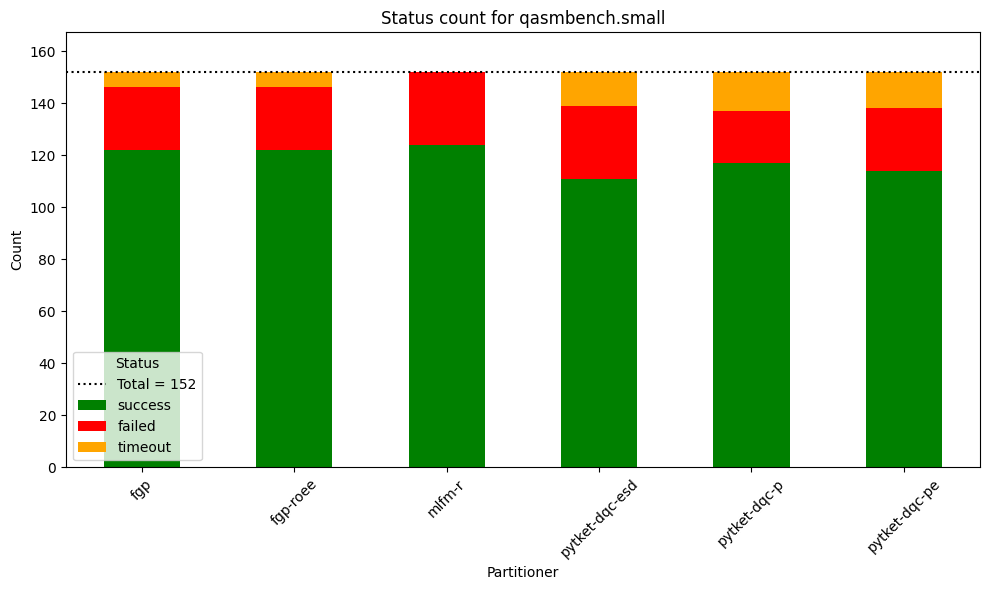

In [5]:
# For each benchmark, plot status count for each partitioner: a bar plot with partitioner on x-axis and count of each status as stacked bars, with different colors for each status
for benchmark, benchmark_df in results_df.groupby("benchmark"):
    plt.figure(figsize=(10, 6))
    status_counts = benchmark_df.groupby(["partitioner", "status"]).size().unstack(fill_value=0)

    status_order = [s for s in STATUS_COLORS if s in status_counts.columns]
    status_counts = status_counts.reindex(columns=status_order)
    
    totals = status_counts.sum(axis=1)
    total = int(totals.max()) if not totals.empty else 0

    ax = status_counts.plot(
        kind="bar",
        stacked=True,
        color=[STATUS_COLORS.get(s, "gray") for s in status_counts.columns],
        figsize=(10, 6),
    )
    ax.axhline(total, linestyle=":", color="black", linewidth=1.5, label=f"Total = {total}")

    ax.set_title(f"Status count for {benchmark}")
    ax.set_xlabel("Partitioner")
    ax.set_ylabel("Count")
    ax.set_ylim(0, total * 1.1 if total > 0 else 1)
    ax.legend(title="Status")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

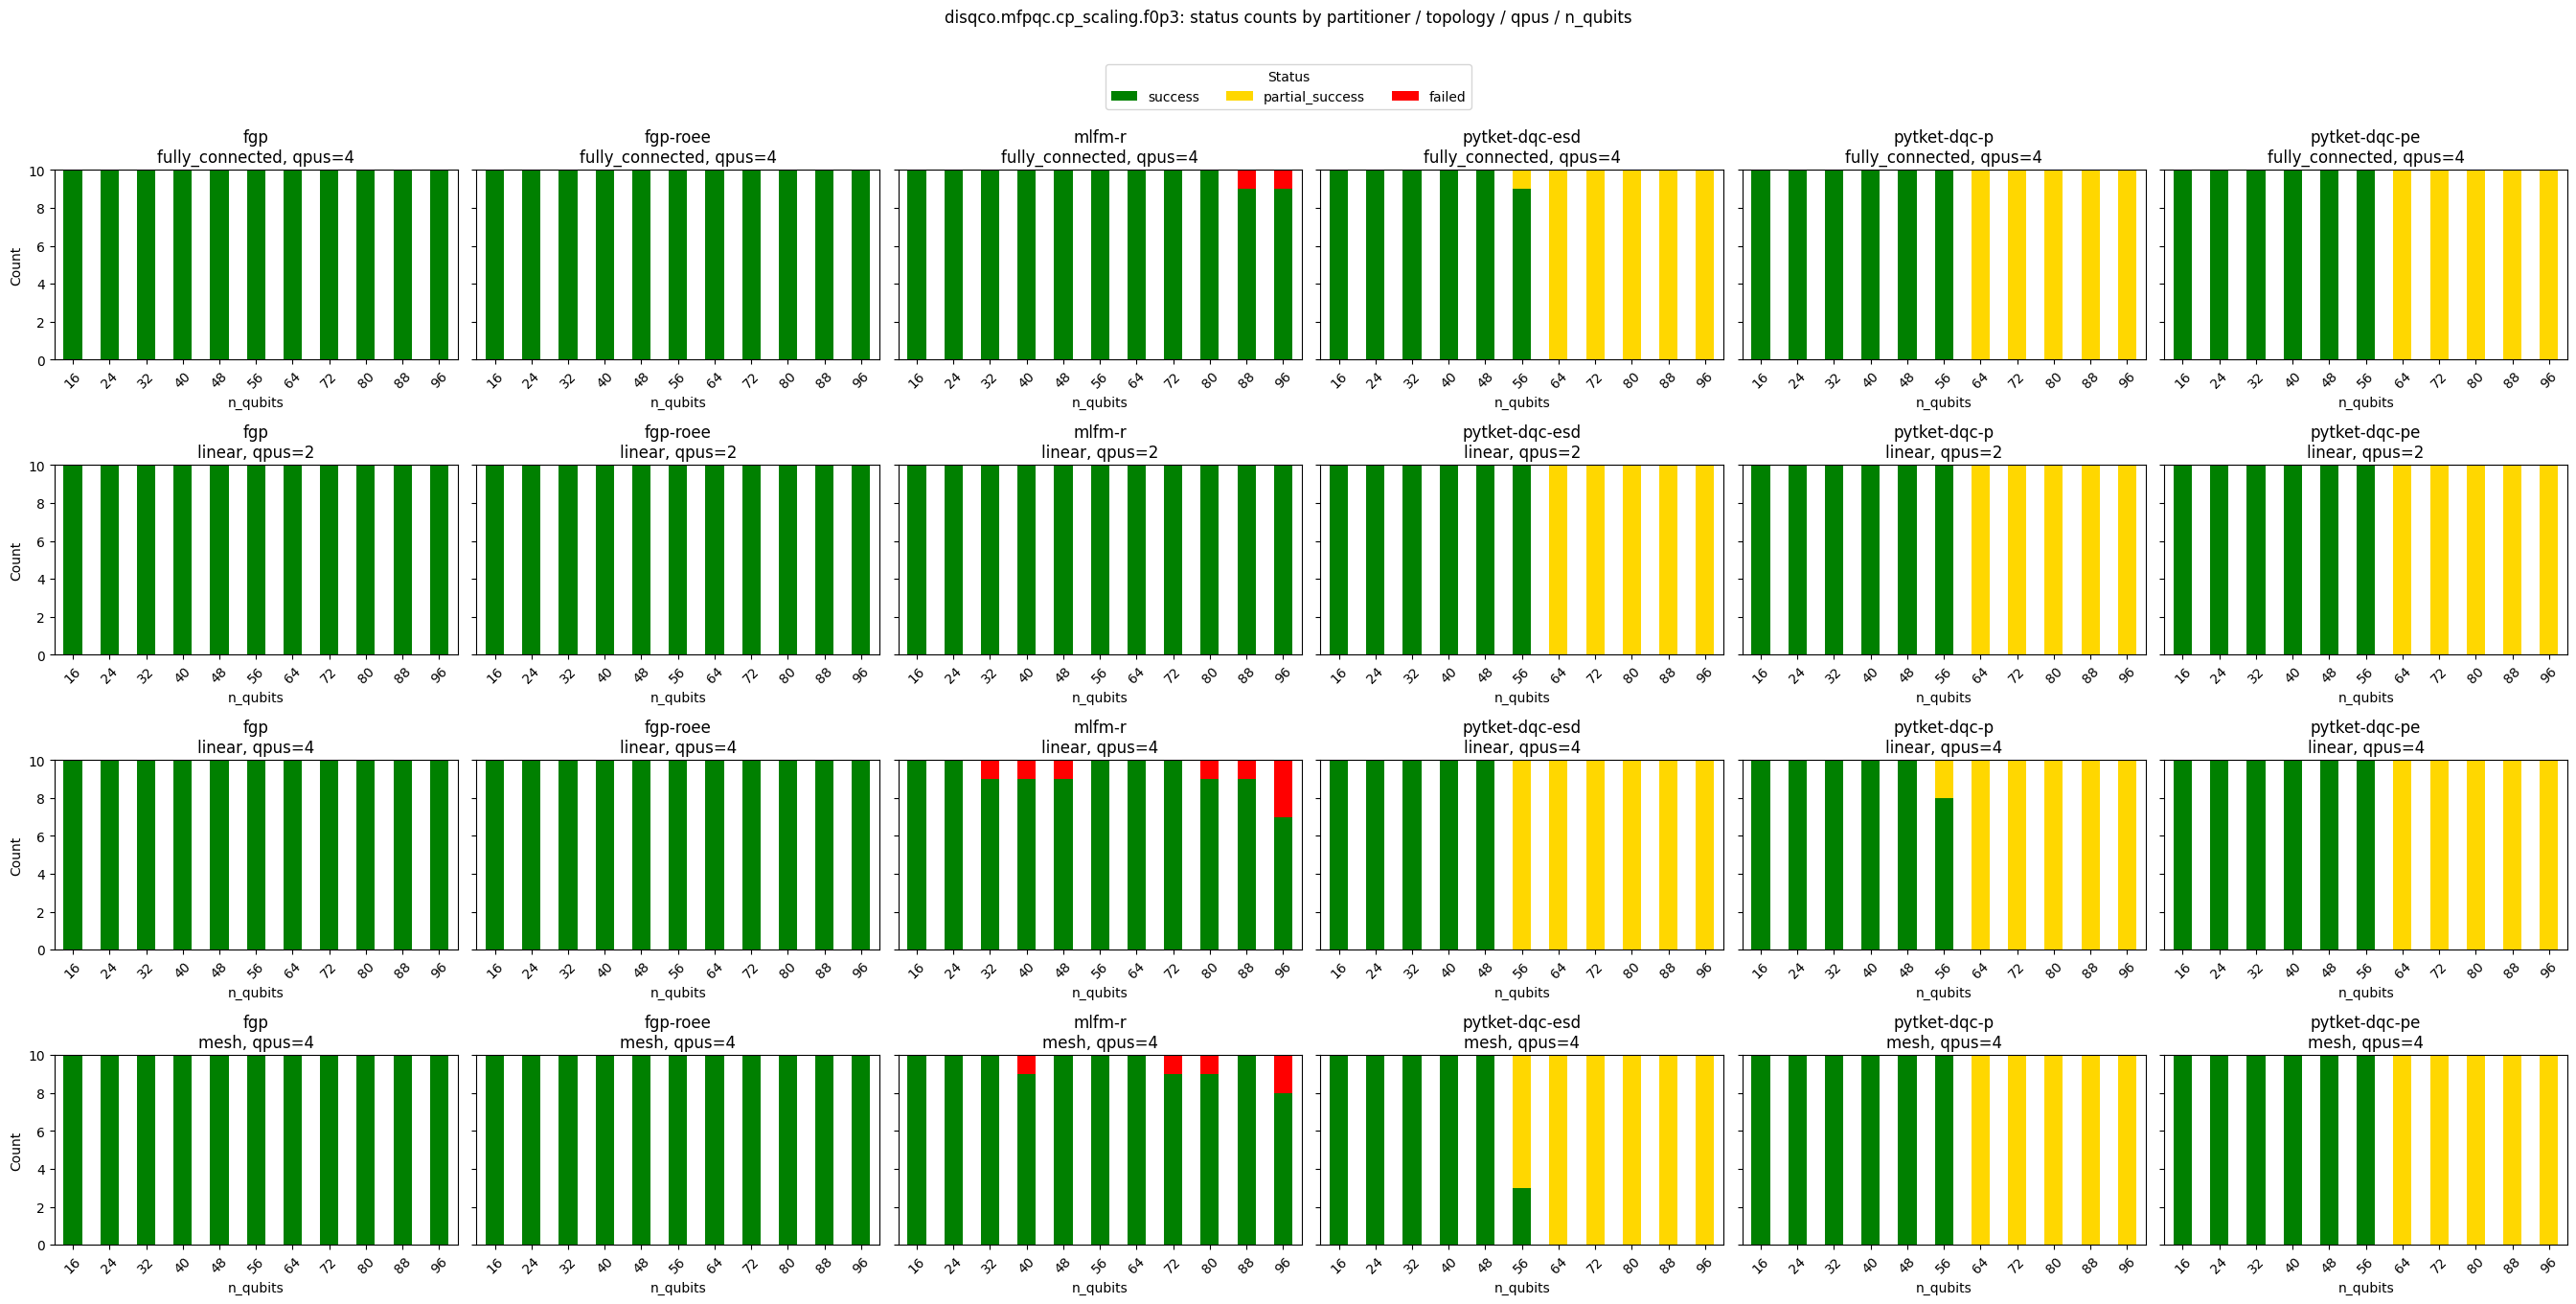

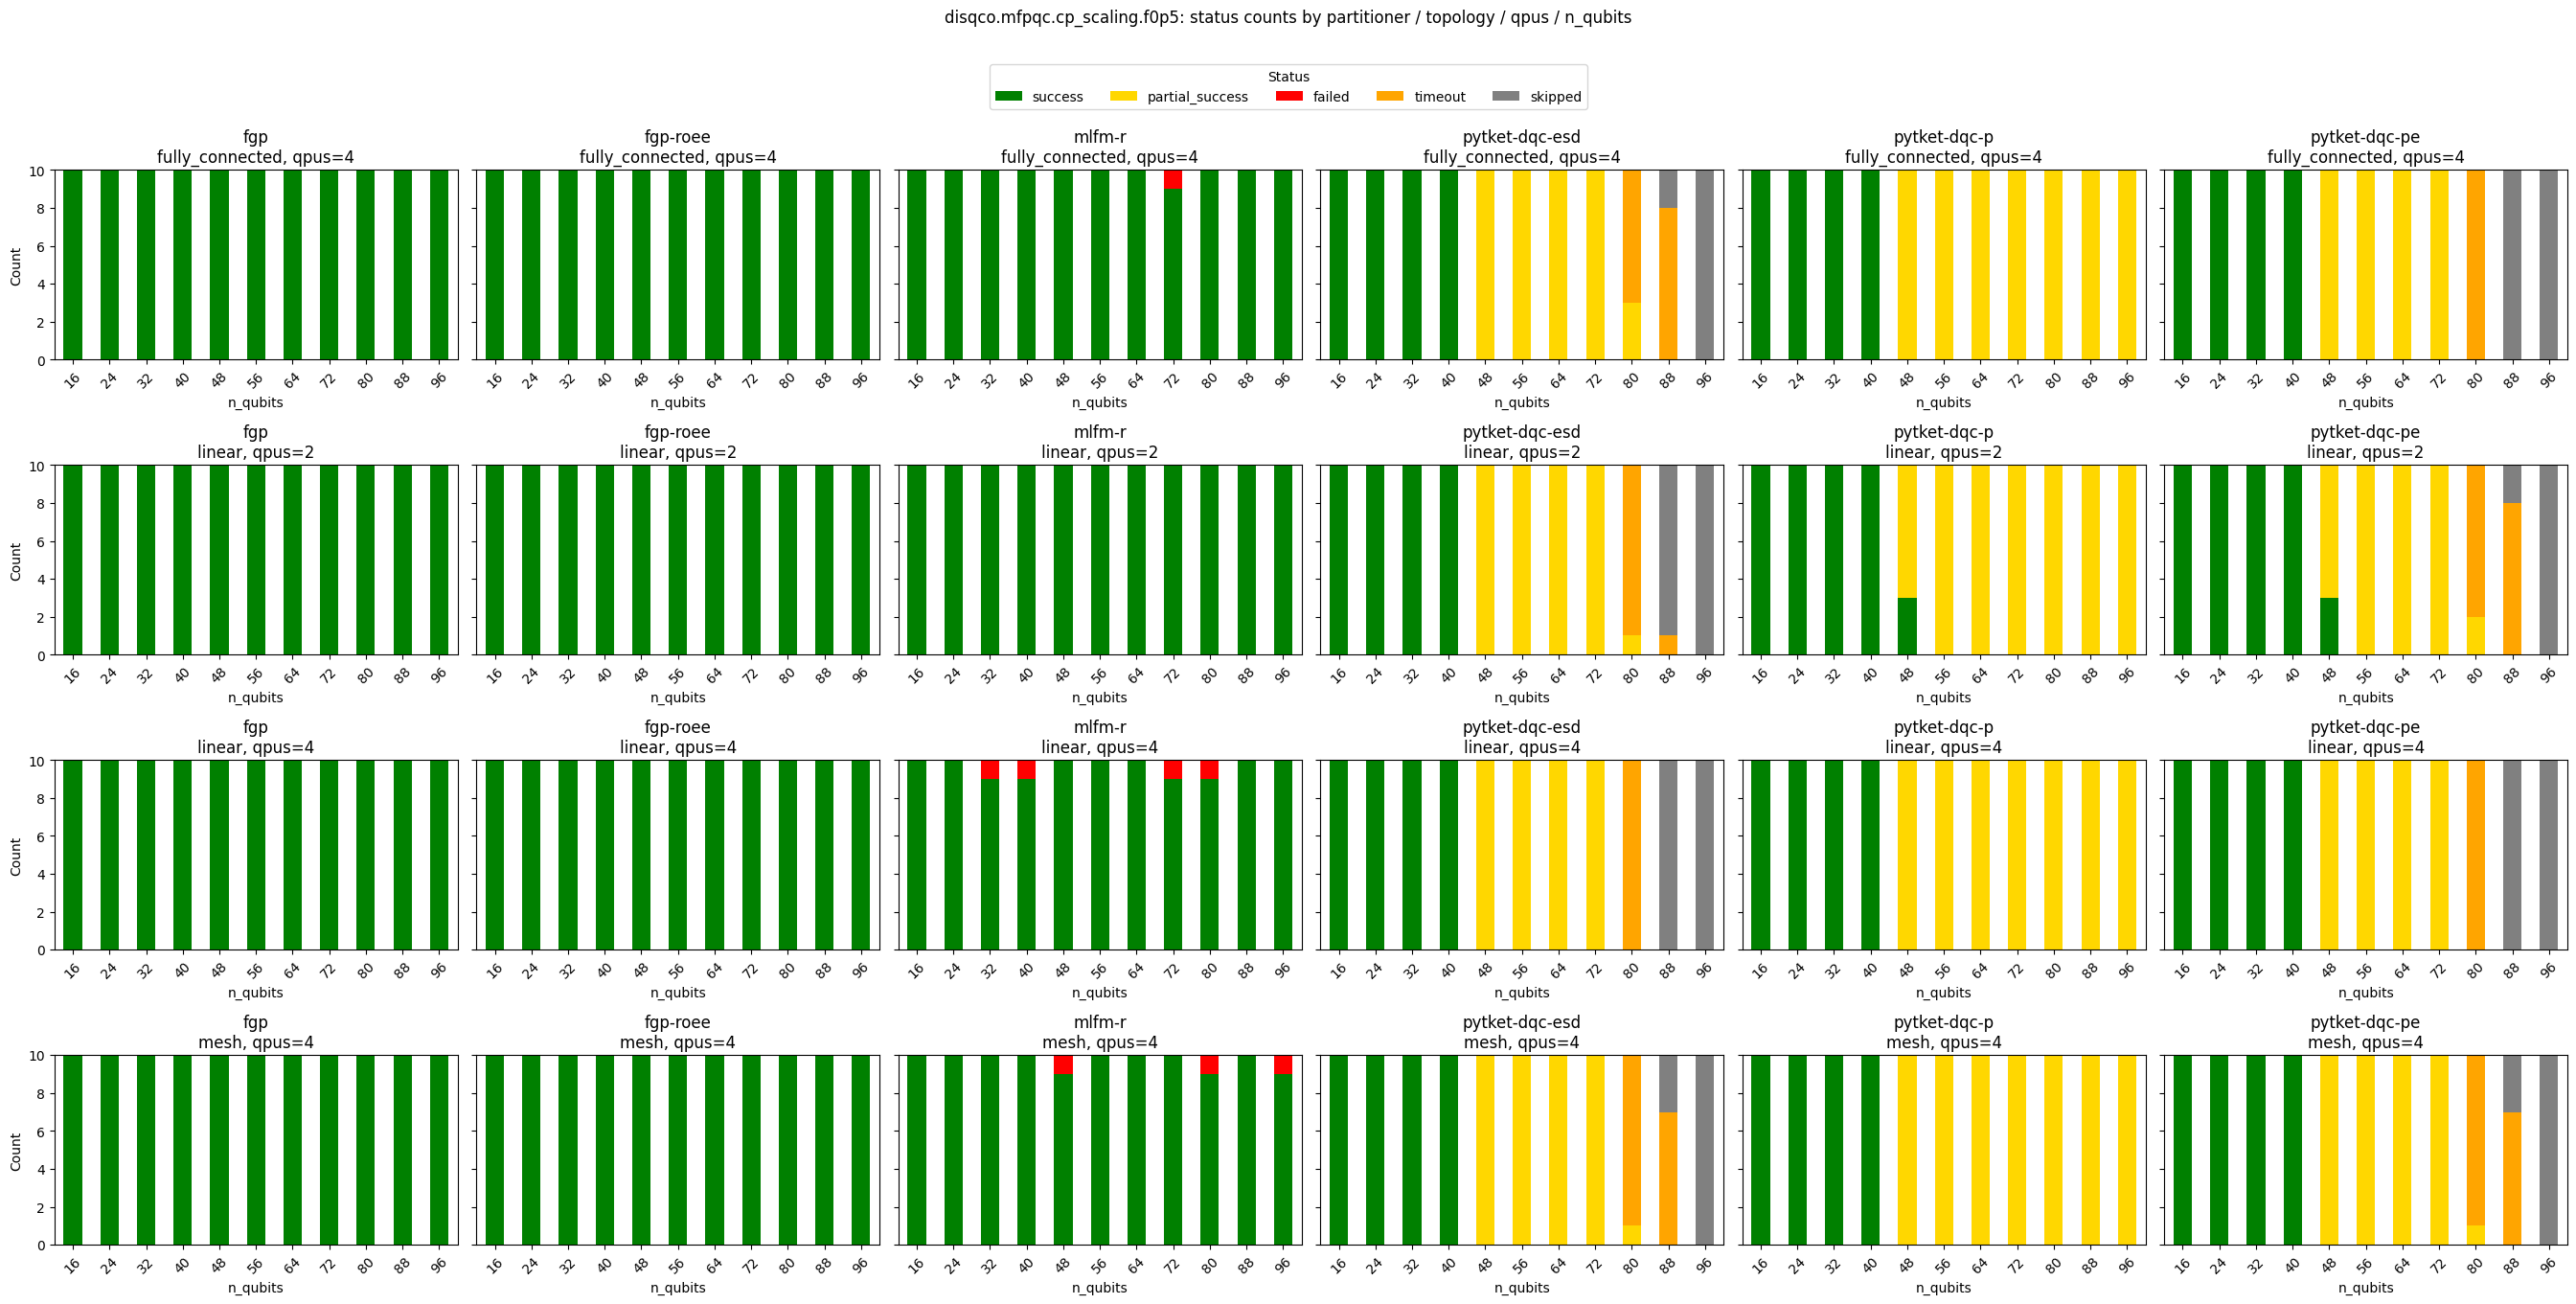

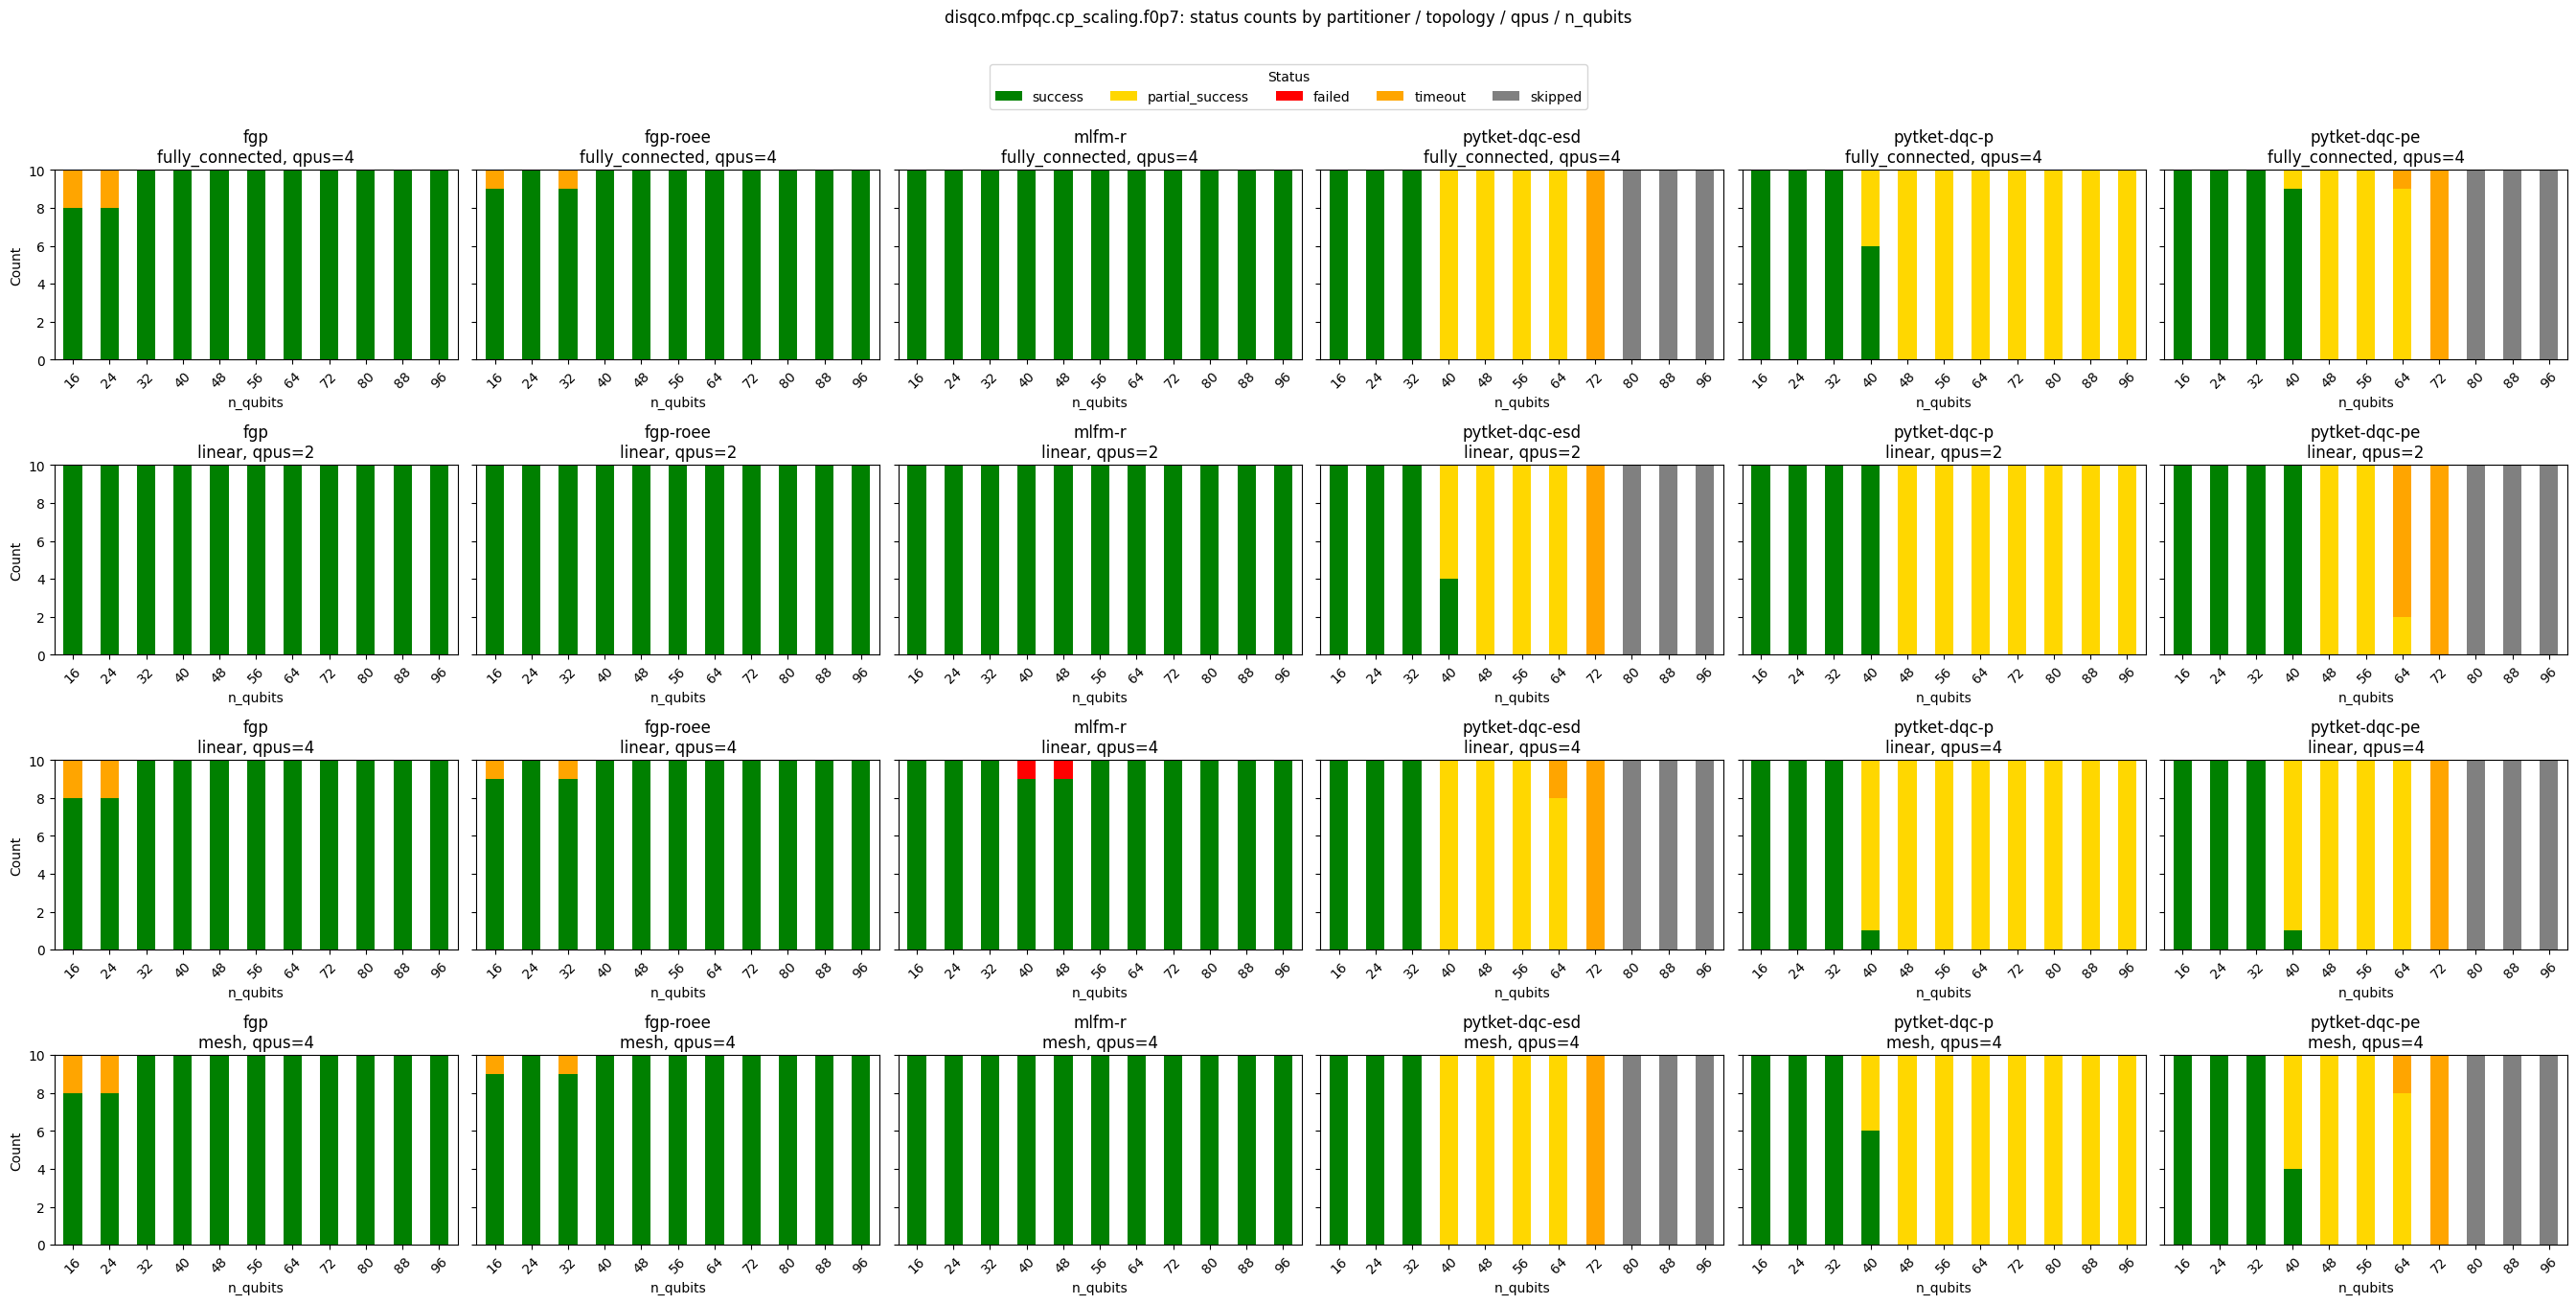

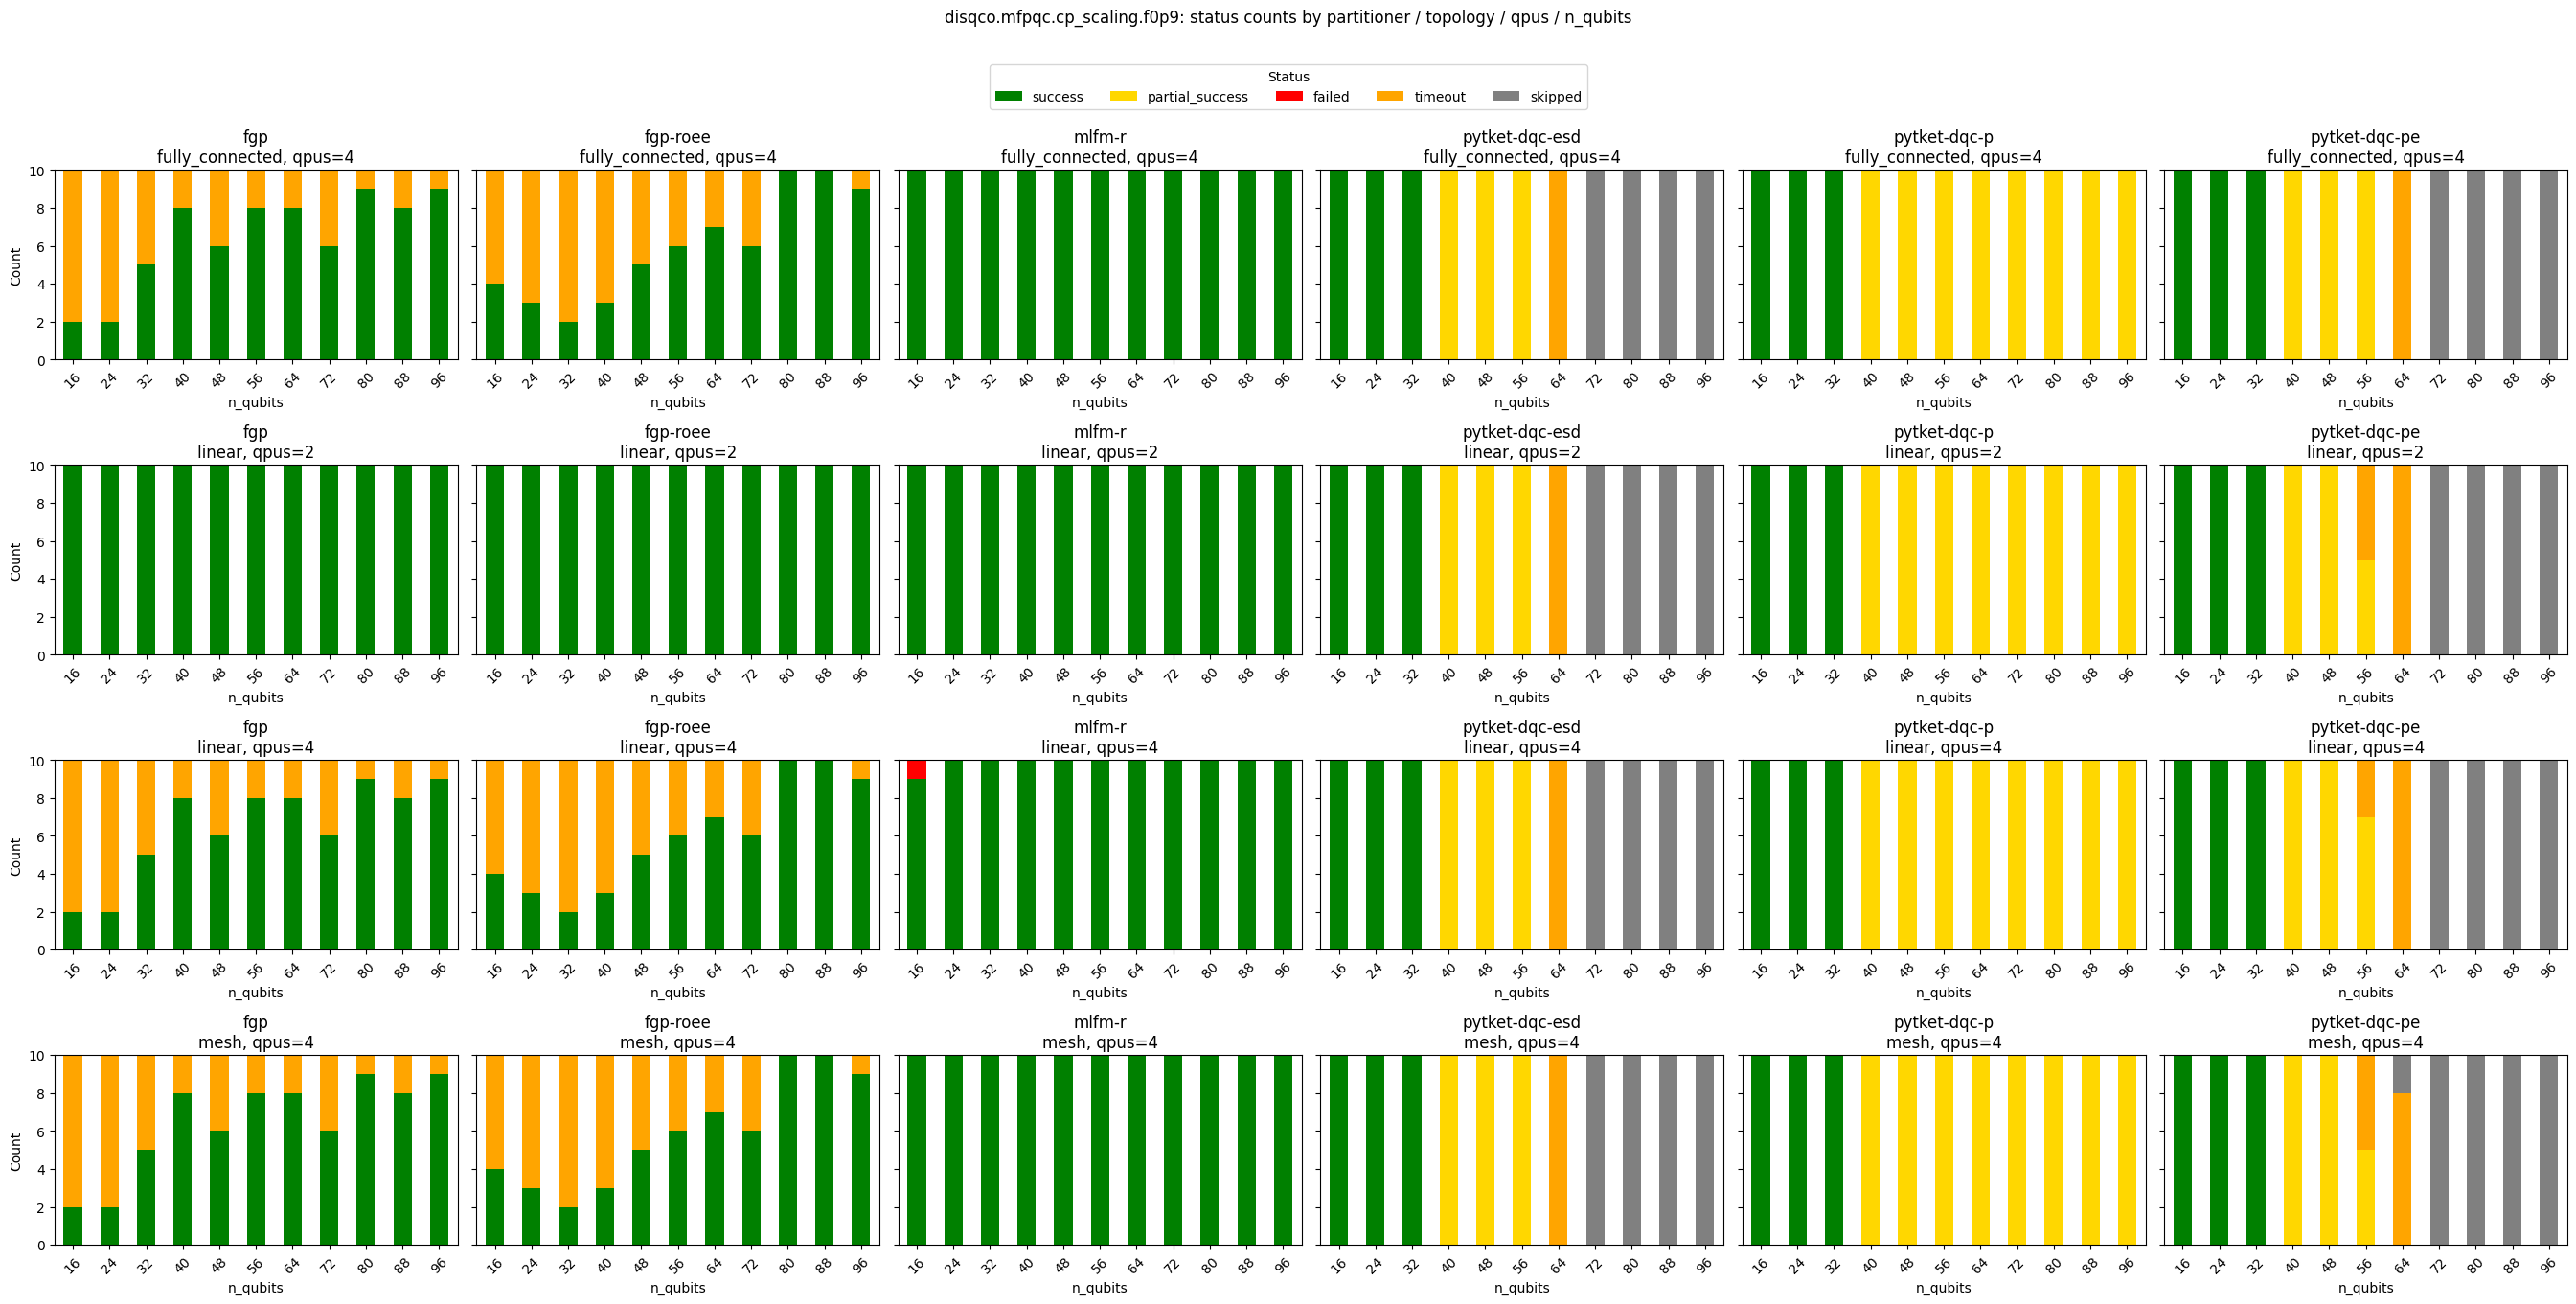

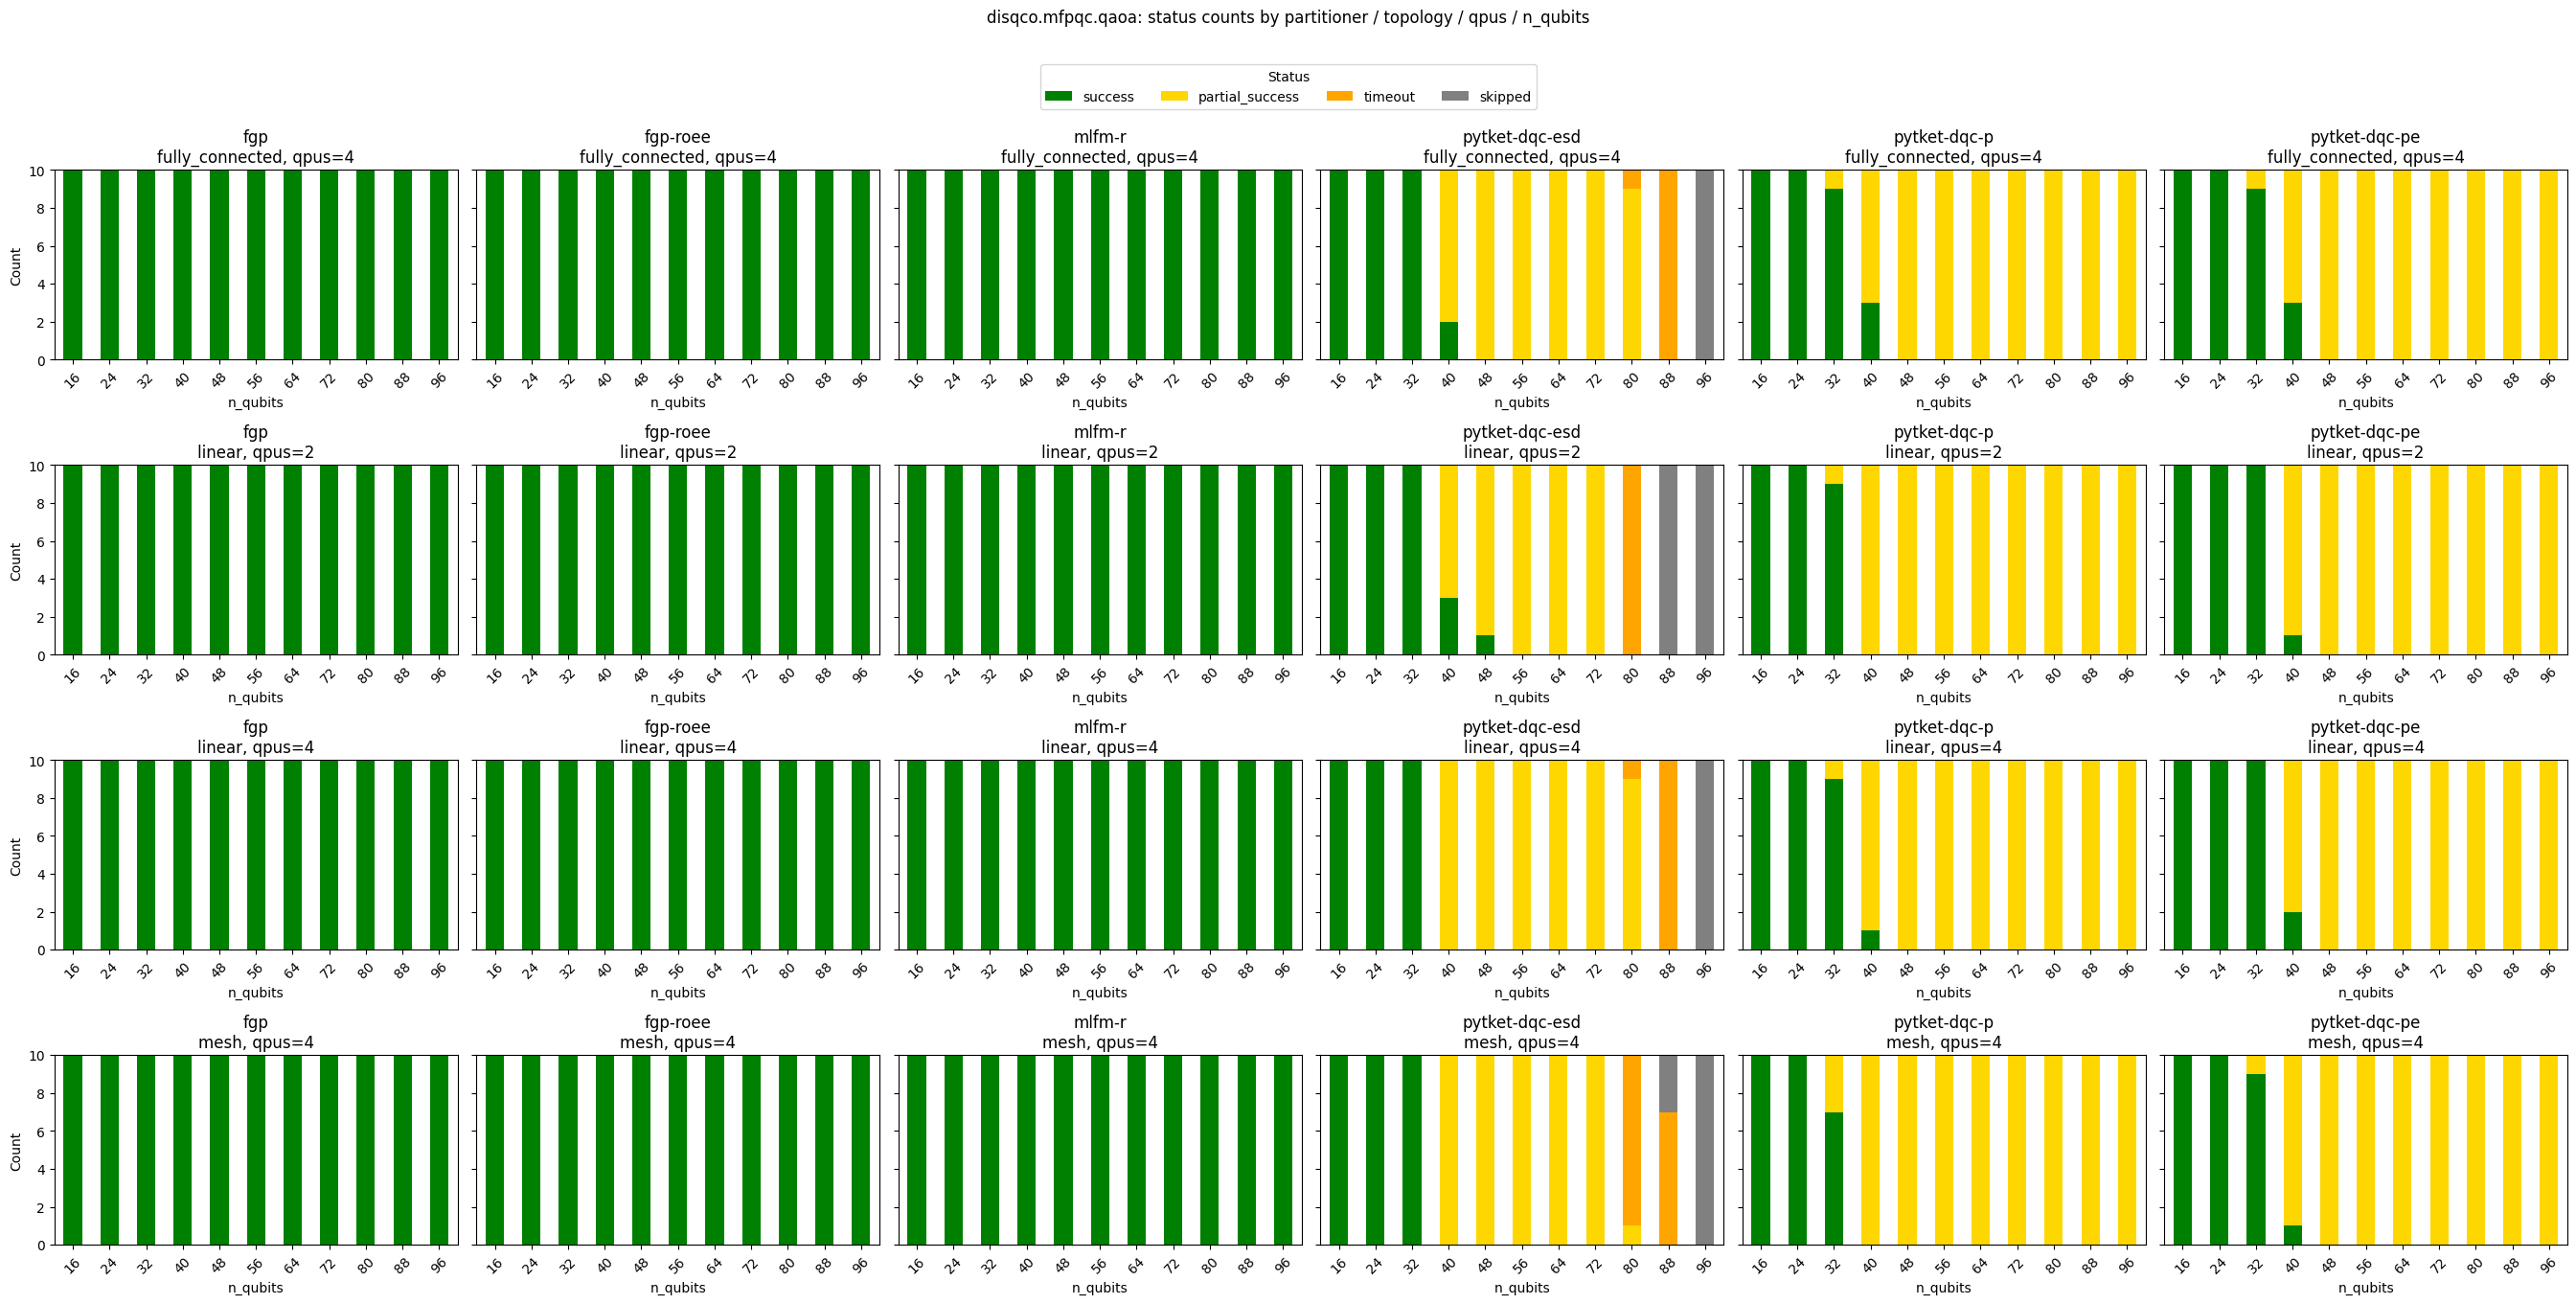

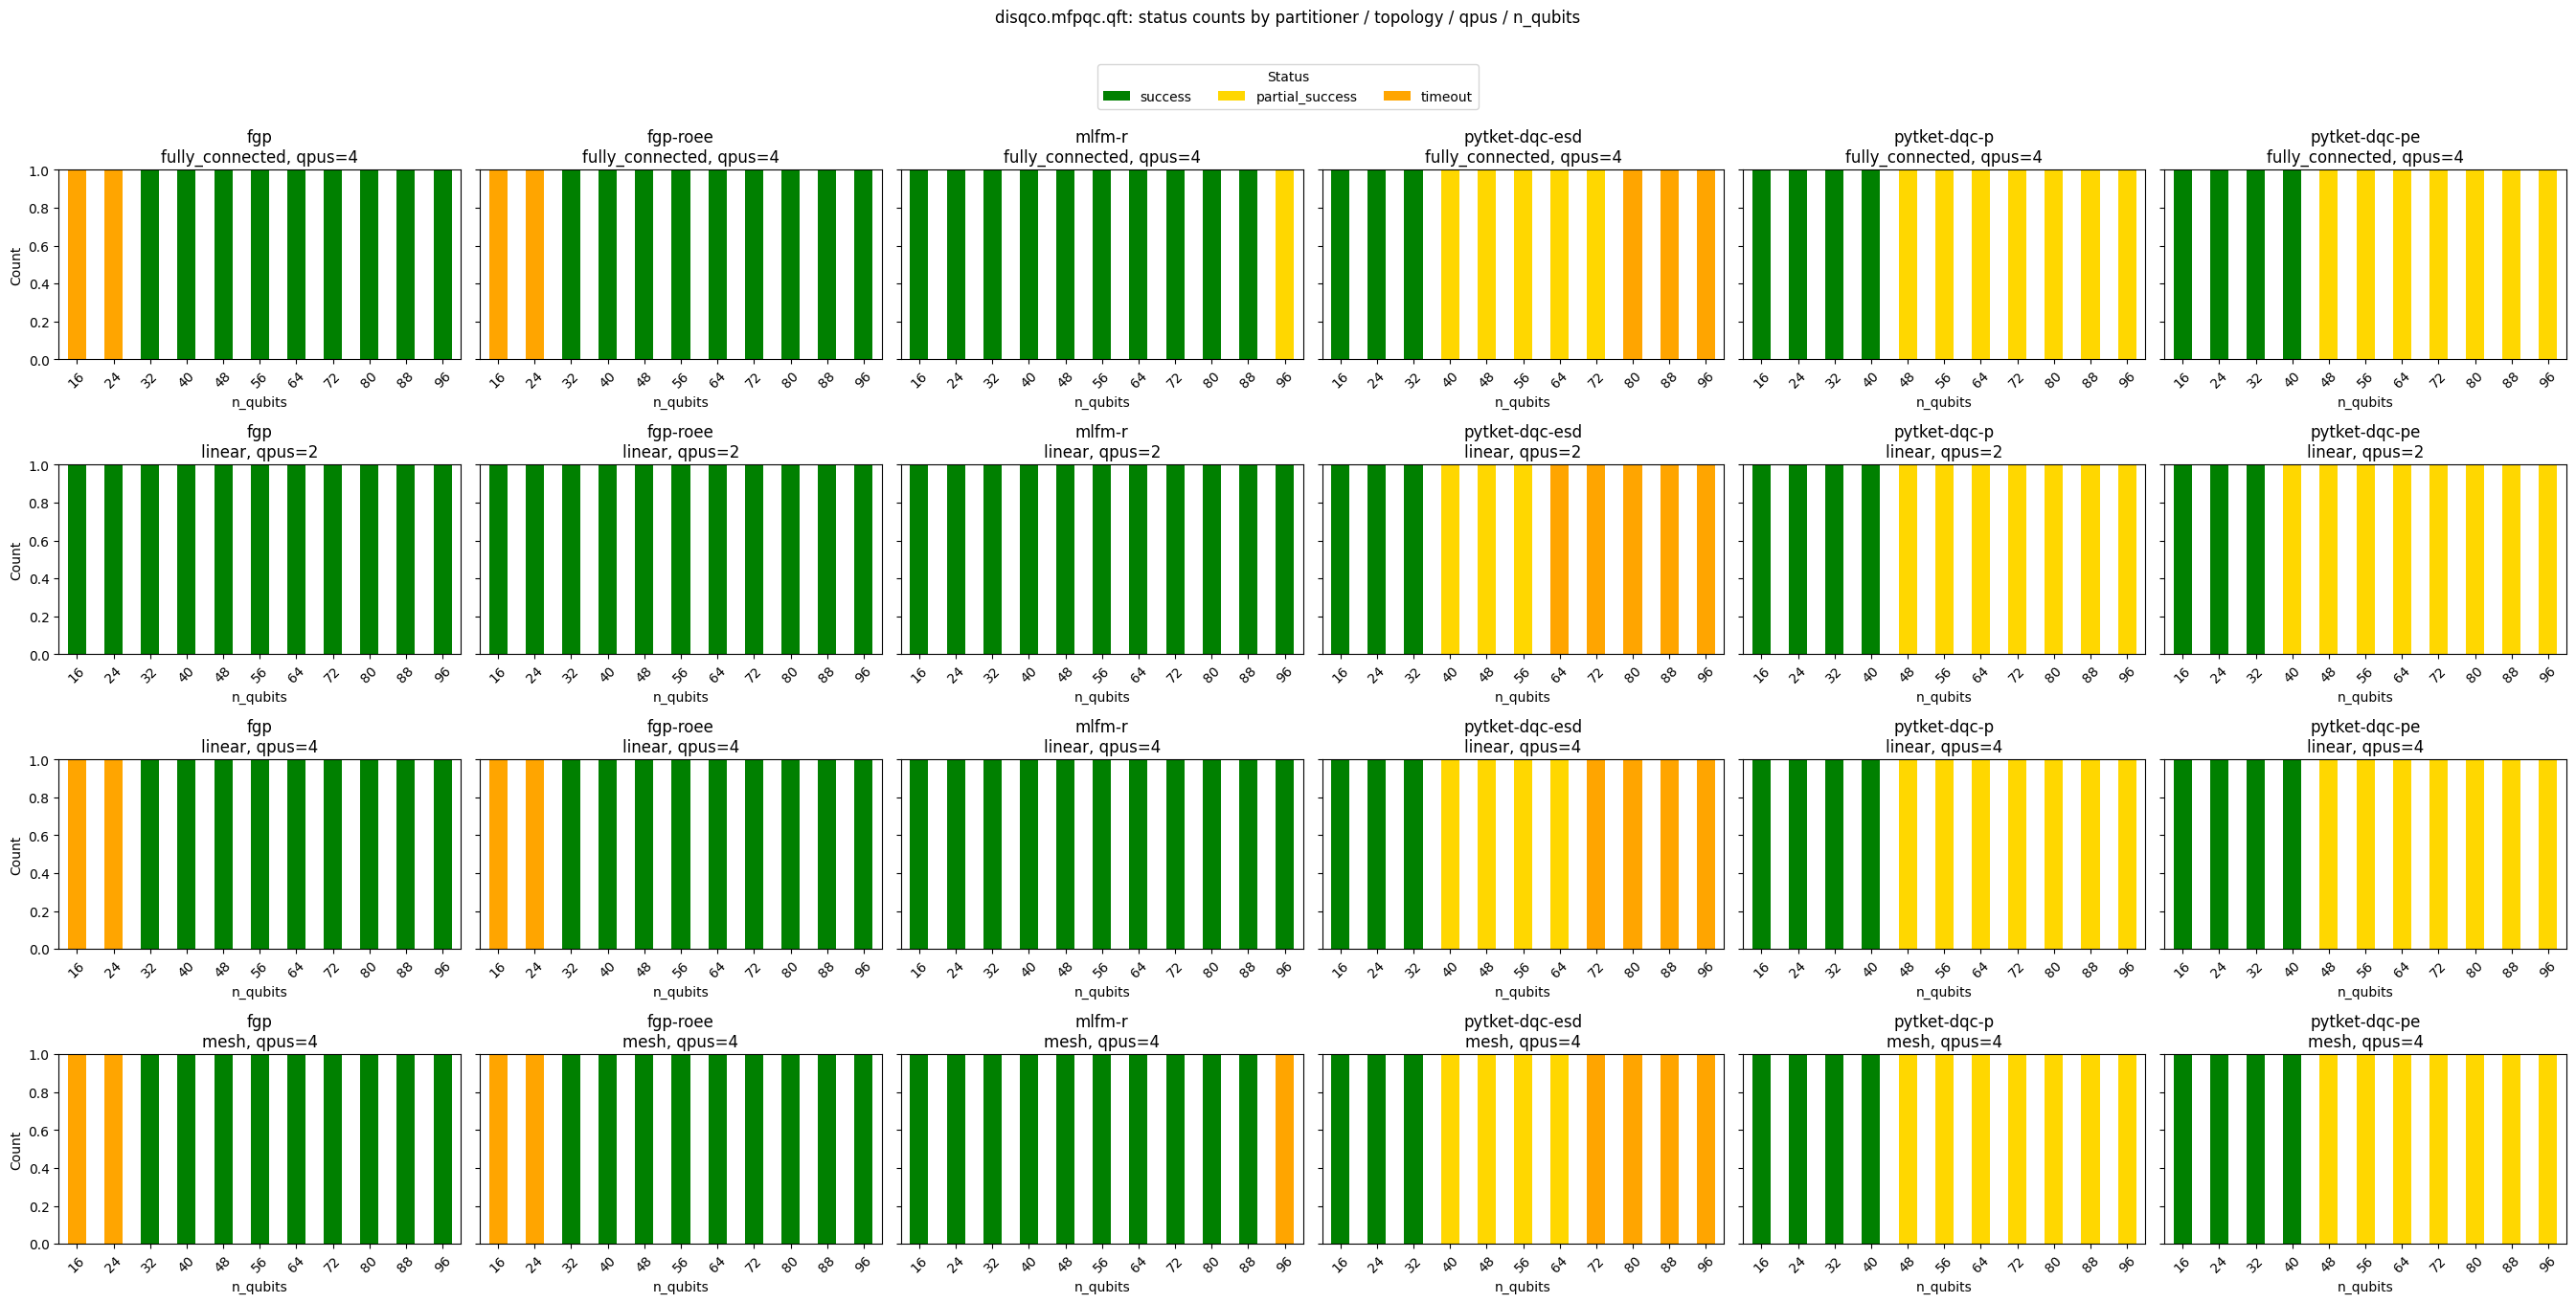

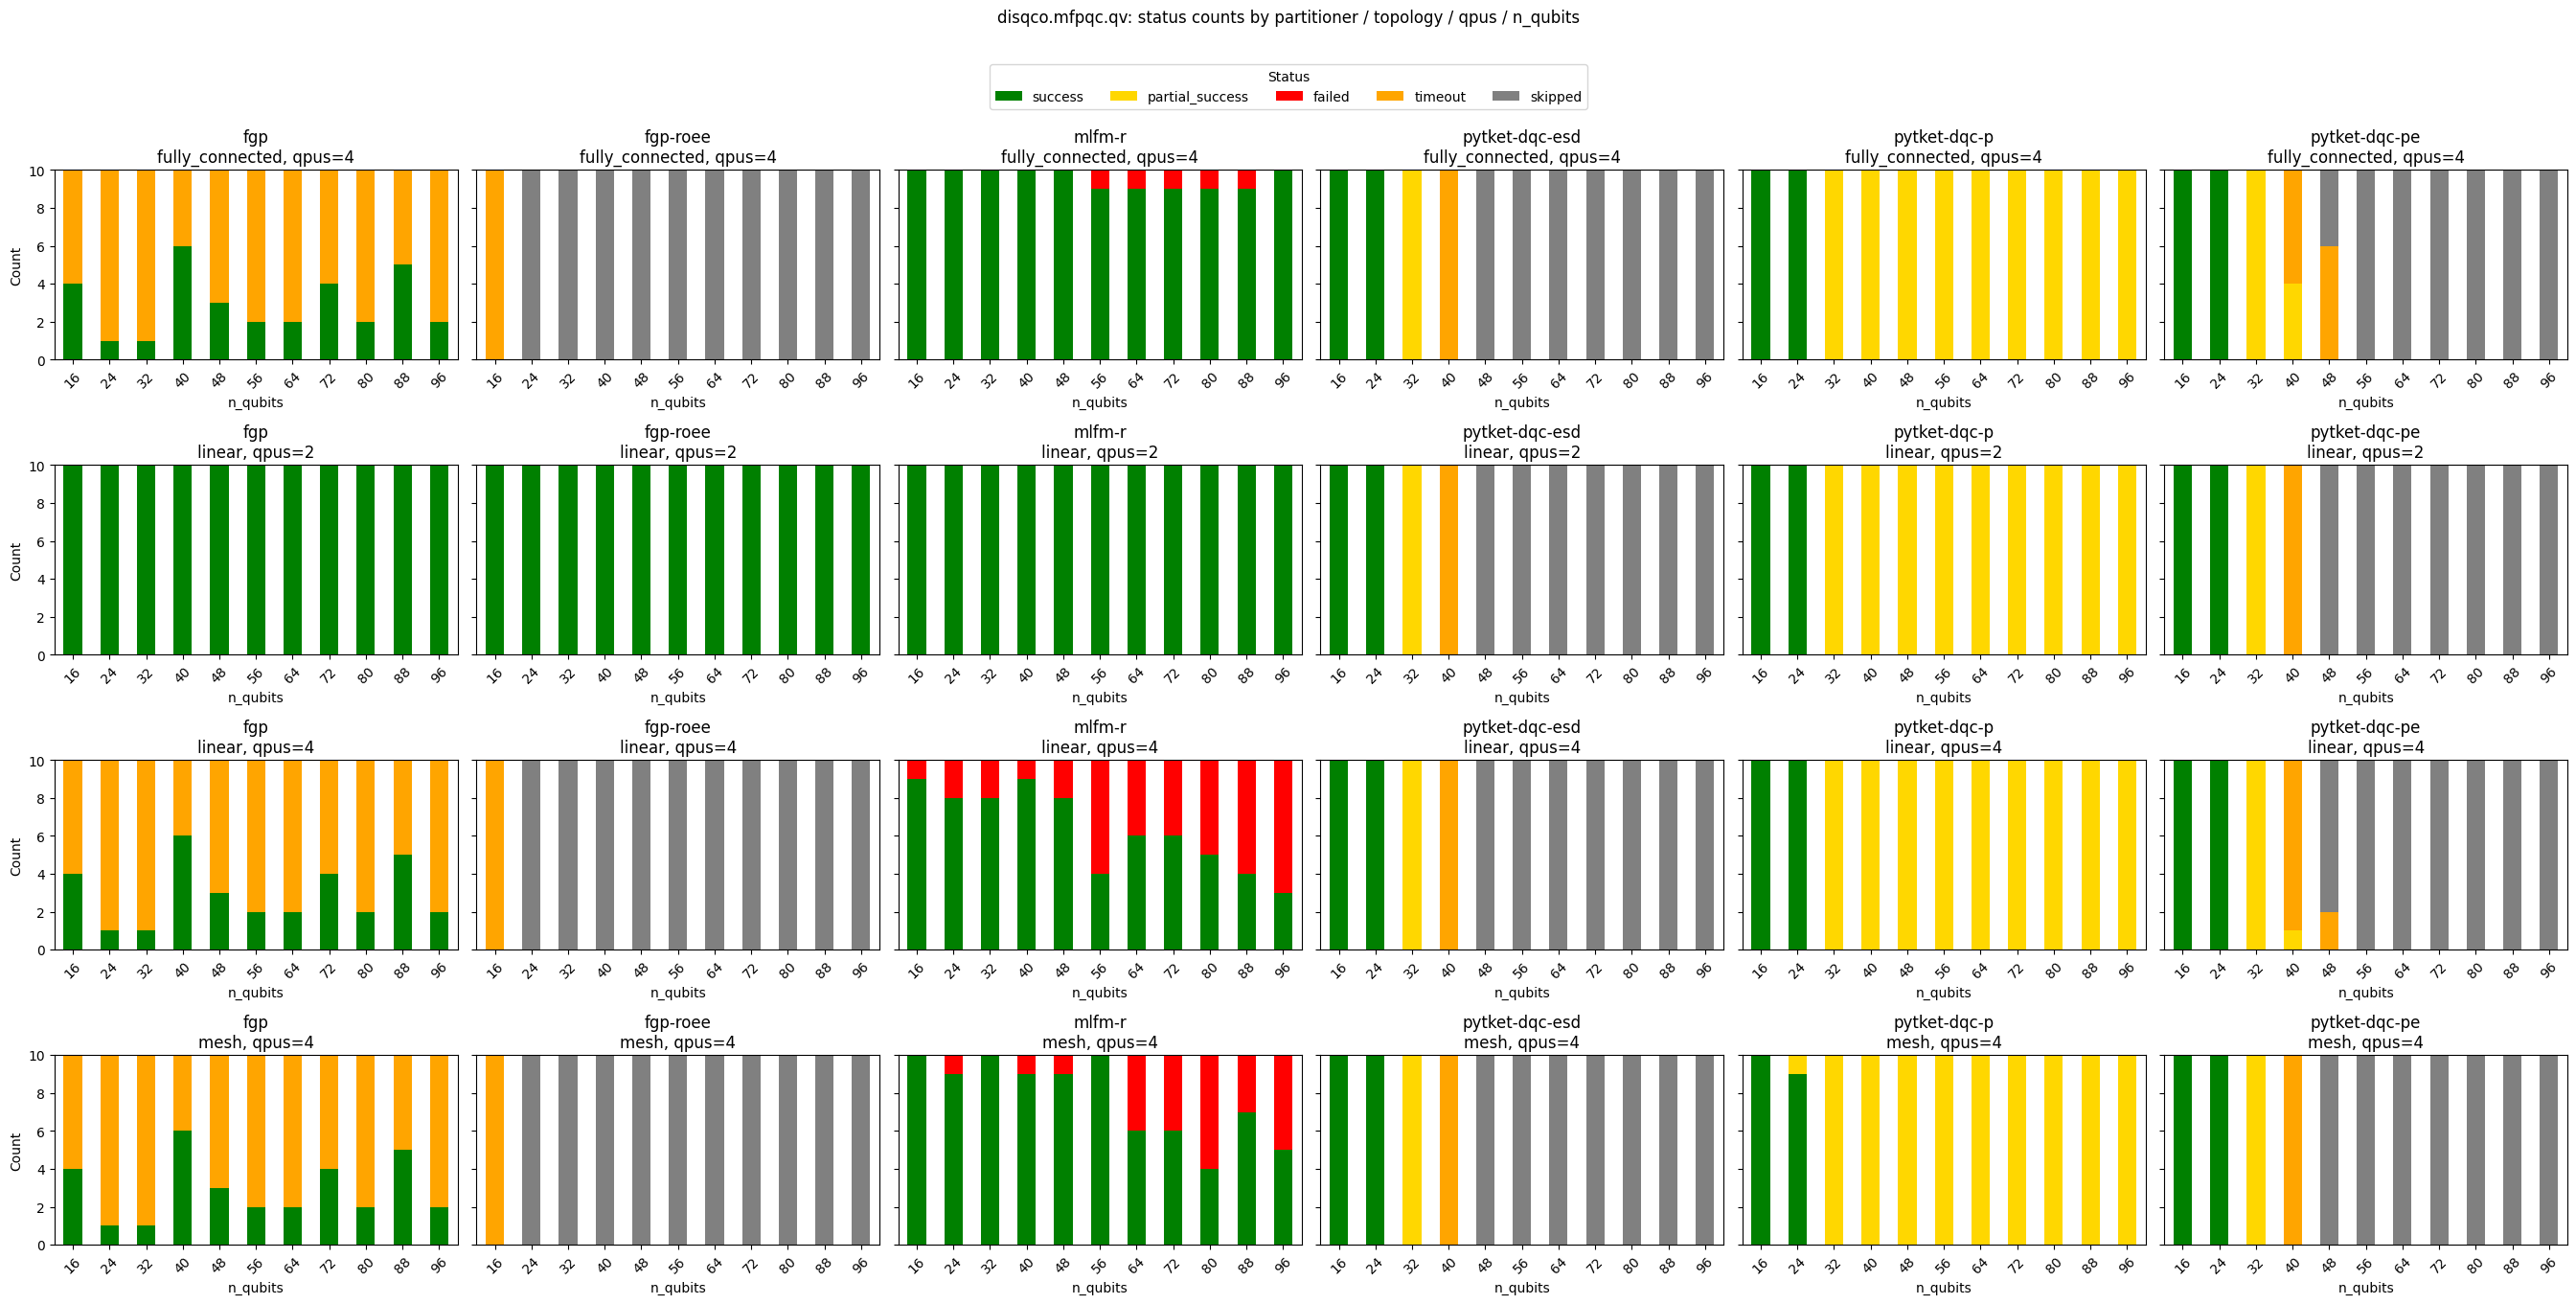

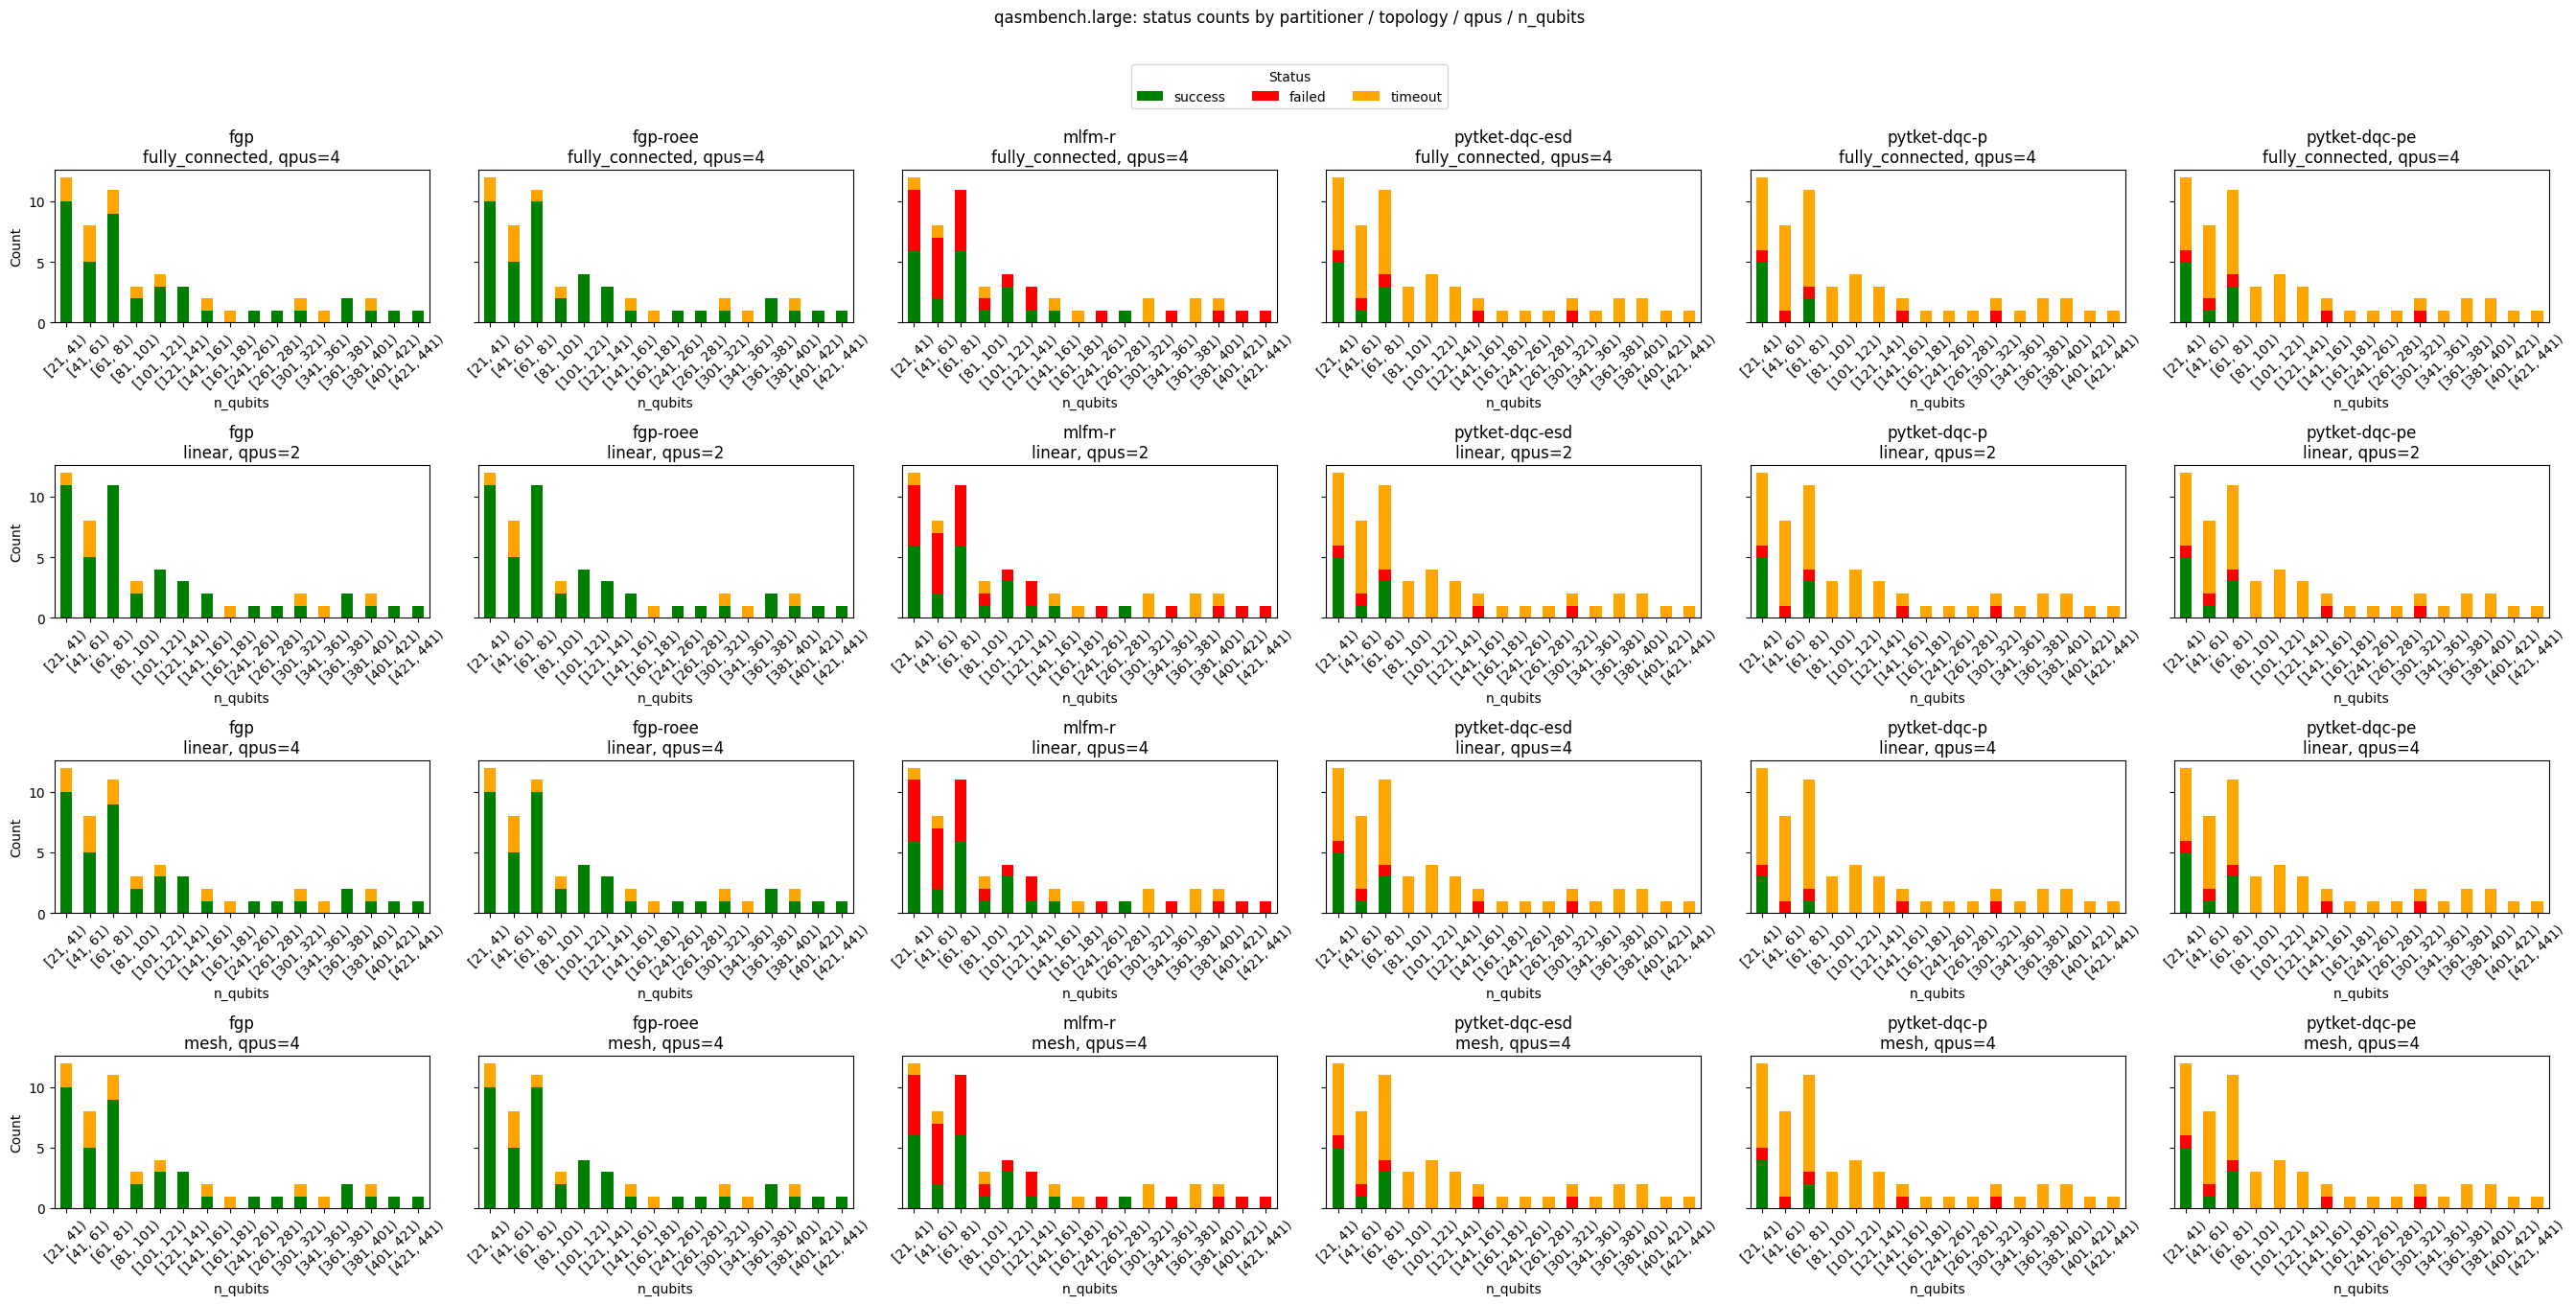

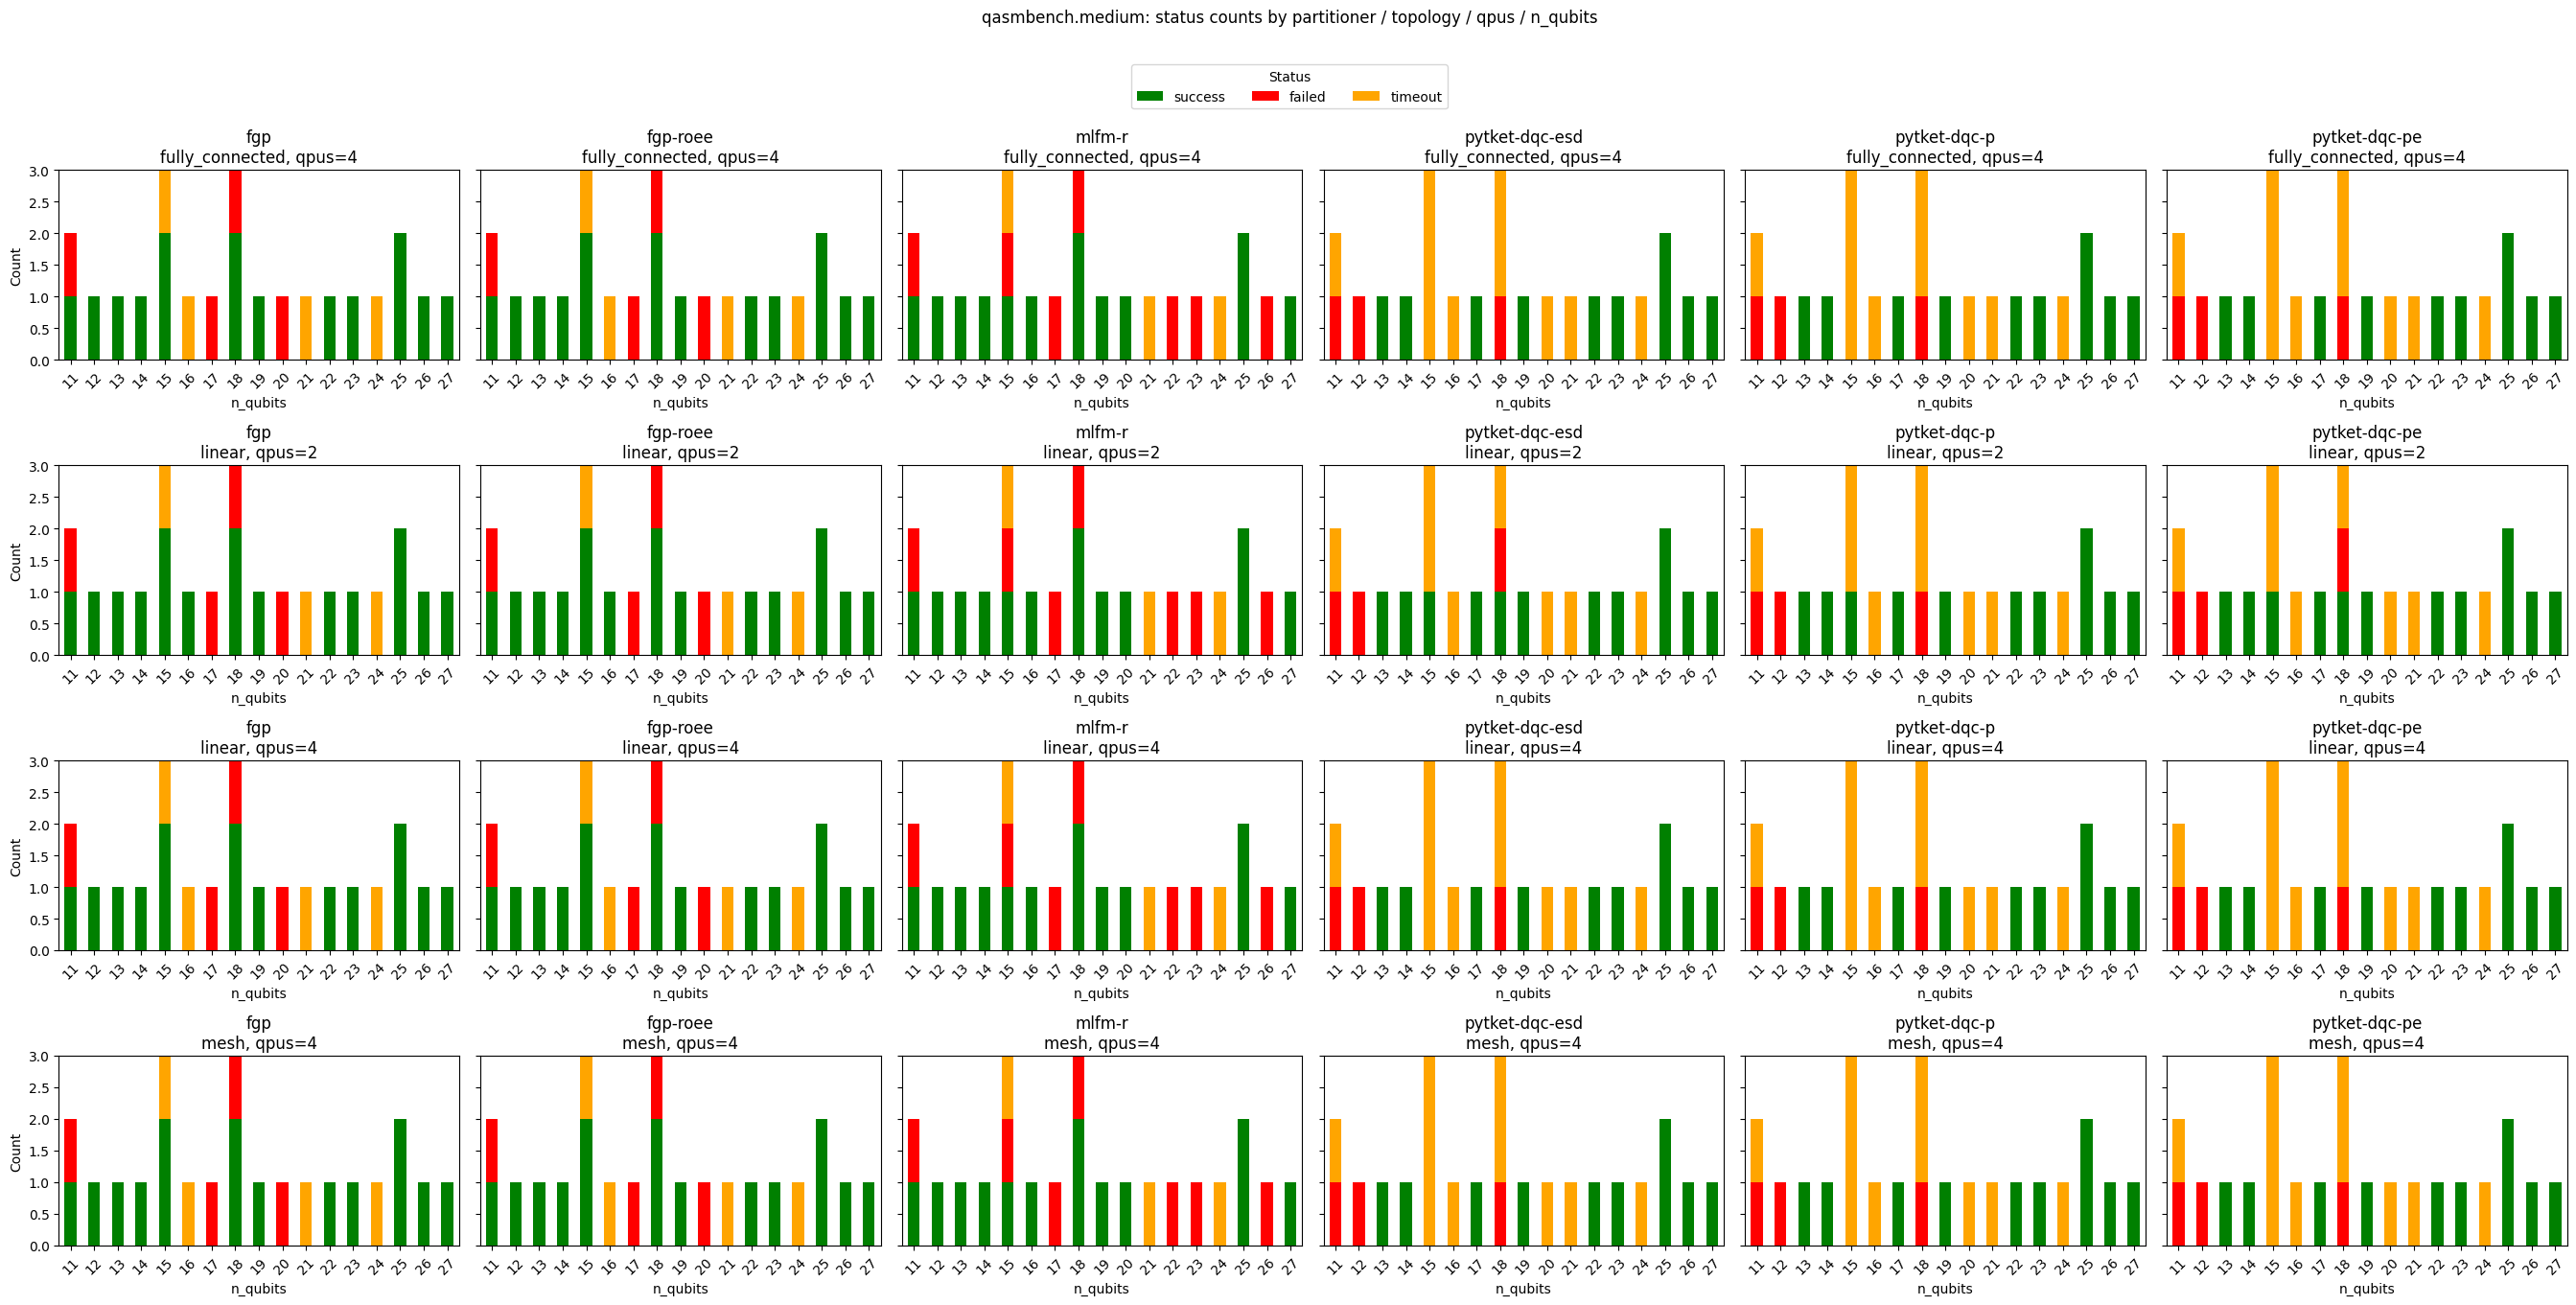

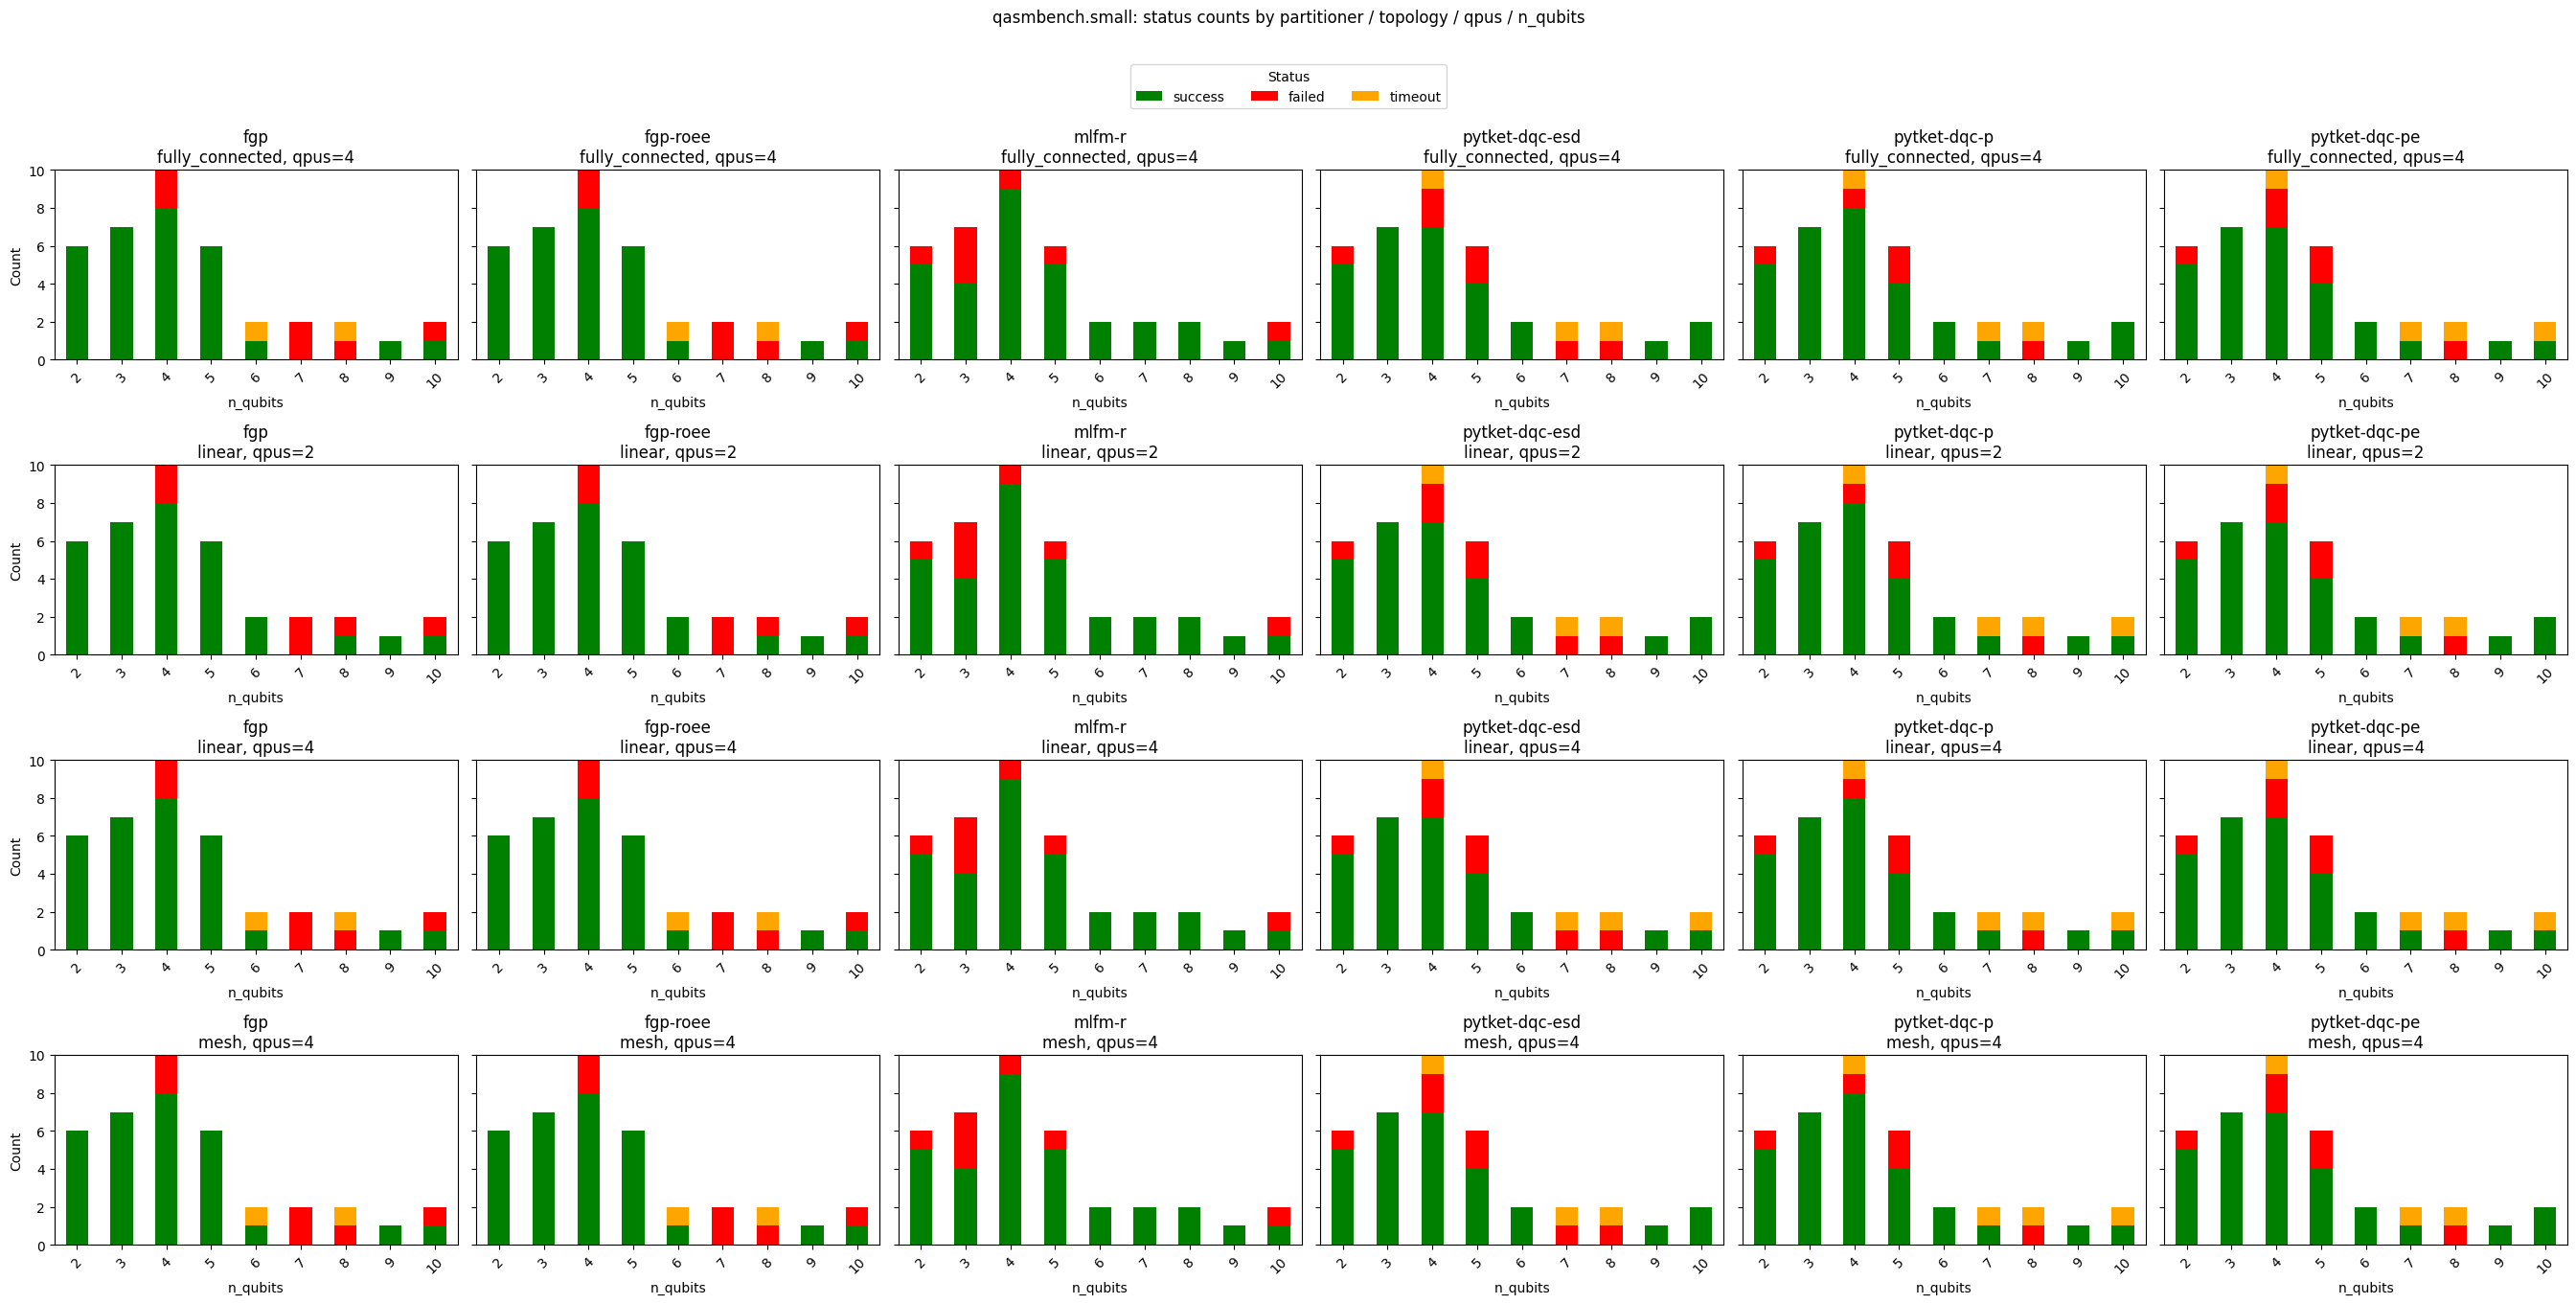

In [6]:
# For each benchmark:
# - one figure
# - columns = partitioners (side by side)
# - rows = (network_topology, num_qpus) combinations (top to bottom)
# - each subplot: bars over n_qubits, stacked by status
QASMBENCH_LARGE_BIN_SIZE = 20  
for benchmark, benchmark_df in results_df.groupby("benchmark"):
    partitioners = sorted(benchmark_df["partitioner"].dropna().unique())
    topo_qpu_combos = (
        benchmark_df[["network_topology", "num_qpus"]]
        .drop_duplicates()
        .sort_values(["network_topology", "num_qpus"])
    )
    topo_qpu_combos = list(topo_qpu_combos.itertuples(index=False, name=None))

    statuses_in_data = list(pd.Series(benchmark_df["status"].dropna().unique()))
    statuses = [s for s in STATUS_COLORS if s in statuses_in_data] + [
        s for s in statuses_in_data if s not in STATUS_COLORS
    ]

    n_rows = max(1, len(topo_qpu_combos))
    n_cols = max(1, len(partitioners))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 3.2 * n_rows),
        sharey=True,
    )

    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [axes]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]

    legend_handles, legend_labels = None, None

    for r, (network_topology, num_qpus) in enumerate(topo_qpu_combos):
        for c, partitioner in enumerate(partitioners):
            ax = axes[r][c]

            sub_df = benchmark_df[
                (benchmark_df["network_topology"] == network_topology)
                & (benchmark_df["num_qpus"] == num_qpus)
                & (benchmark_df["partitioner"] == partitioner)
            ]

            if sub_df.empty:
                ax.set_title(f"{partitioner}\n{network_topology}, qpus={num_qpus}")
                ax.set_xlabel("n_qubits")
                if c == 0:
                    ax.set_ylabel("Count")
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_xticks([])
                continue

            if benchmark == "qasmbench.large":
                qmin = int(sub_df["n_qubits"].min())
                qmax = int(sub_df["n_qubits"].max())
                start = ((qmin - 1) // QASMBENCH_LARGE_BIN_SIZE) * QASMBENCH_LARGE_BIN_SIZE + 1
                end = ((qmax - 1) // QASMBENCH_LARGE_BIN_SIZE + 1) * QASMBENCH_LARGE_BIN_SIZE + 1
                bins = np.arange(start, end + 1, QASMBENCH_LARGE_BIN_SIZE)

                sub_df = sub_df.copy()
                sub_df["n_qubits_bin"] = pd.cut(
                    sub_df["n_qubits"],
                    bins=bins,
                    right=False,
                    include_lowest=True,
                )

                status_counts = (
                    sub_df.groupby(["n_qubits_bin", "status"])
                    .size()
                    .unstack(fill_value=0)
                    .reindex(columns=statuses, fill_value=0)
                )
            else:
                status_counts = (
                    sub_df.groupby(["n_qubits", "status"])
                    .size()
                    .unstack(fill_value=0)
                    .reindex(columns=statuses, fill_value=0)
                    .sort_index()
                )

            status_order = [s for s in STATUS_COLORS if s in status_counts.columns]
            status_counts = status_counts.reindex(columns=status_order)

            status_counts.plot(
                kind="bar",
                stacked=True,
                ax=ax,
                color=[STATUS_COLORS.get(s, "gray") for s in status_counts.columns],
                legend=False,
            )

            ax.set_title(f"{partitioner}\n{network_topology}, qpus={num_qpus}")
            ax.set_xlabel("n_qubits")
            if c == 0:
                ax.set_ylabel("Count")
            else:
                ax.set_ylabel("")
            ax.tick_params(axis="x", rotation=45)

            if legend_handles is None and len(status_counts.columns) > 0:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            title="Status",
            loc="upper center",
            ncol=max(1, len(legend_labels)),
            bbox_to_anchor=(0.5, 1.02),
        )

    fig.suptitle(f"{benchmark}: status counts by partitioner / topology / qpus / n_qubits", y=1.06)
    plt.tight_layout()
    plt.show()